# Anemia.csv için PyTorch + Colab Eğitim Notebook'u

Bu notebook **öğrenci dostu** olacak şekilde hazırlandı.  
Amaç sadece model çalıştırmak değil, aynı zamanda şu kavramları da adım adım öğretmektir:

- epoch nedir
- batch nedir
- optimizer nedir
- neden standardization yapılır
- neden farklı katman sayıları denenir
- neden farklı aktivasyon fonksiyonları kullanılır
- neden farklı optimizer'lar karşılaştırılır
- loss, accuracy, precision, recall, F1 ve AUC nasıl yorumlanır
- feature importance ve XAI ne gösterir

## Bu notebook'ta neler var?
- Google Drive'dan `anemia.csv` okuma
- veri inceleme ve EDA
- eksik değer analizi
- histogram, boxplot, violinplot, KDE, korelasyon
- train / validation / test split
- PyTorch Dataset ve DataLoader
- **çok sayıda ANN modeli**
- farklı:
  - katman sayıları
  - nöron sayıları
  - aktivasyon fonksiyonları
  - optimizer'lar
  - epoch sayıları
  - dropout seçenekleri
- eğitim döngüsünün satır satır açıklaması
- tüm temel metrik grafikleri
- confusion matrix, ROC, PR, threshold, calibration
- weight importance
- permutation importance
- integrated gradients
- PCA ve t-SNE

## Kullanım
Sadece şu satırı kendi dosya yoluna göre değiştir:
```python
DRIVE_CSV_PATH = "/content/drive/MyDrive/YOUR_FOLDER/anemia.csv"
```
Sonra notebook'u yukarıdan aşağıya sırayla çalıştır.


## Neden bu kurulum hücresi var?

Bazen Colab'da `numpy` ve `pandas` derlenmiş paket sürümleri uyuşmayabiliyor.  
Bunun sonucu olarak şu tip hata çıkabiliyor:

- `ValueError: numpy.dtype size changed, may indicate binary incompatibility`

Bu yüzden notebook'un başına güvenli sürüm sabitlemesi koyduk.


In [1]:
# ============================================================
# 2) KÜTÜPHANELER
# Burada tüm gerekli kütüphaneler içe aktarılır.
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from captum.attr import IntegratedGradients

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("NumPy version :", np.__version__)
print("pandas version:", pd.__version__)
print("PyTorch version:", torch.__version__)


NumPy version : 2.4.4
pandas version: 3.0.3
PyTorch version: 2.12.0+cpu


In [2]:
# ============================================================
# 3) CİHAZ SEÇİMİ
# GPU varsa cuda kullanılır, yoksa cpu ile devam edilir.
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)


Kullanılan cihaz: cpu


## GPU neden önemli?

Yapay sinir ağları çok sayıda matris işlemi yapar.  
GPU bu işlemleri CPU'ya göre çok daha hızlı yapabildiği için eğitim süresini ciddi biçimde azaltır.


In [3]:
# ============================================================
# 4) SEED AYARI
# Rastgeleliği sabitleyerek daha tekrarlanabilir sonuçlar elde ederiz.
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed ayarlandı.")


Seed ayarlandı.


In [4]:
# ============================================================
# 6) DOSYA YOLU
# Buraya kendi anemia.csv dosyanın tam yolunu yaz.
# Örnek:
# /content/drive/MyDrive/datasets/anemia.csv
# ============================================================


DRIVE_CSV_PATH = "./data.csv" 

print("Dosya var mı?:", os.path.exists(DRIVE_CSV_PATH))
print("Seçilen yol:", DRIVE_CSV_PATH)


Dosya var mı?: True
Seçilen yol: ./data.csv


In [6]:
# Veri seti dosya yolu
DRIVE_CSV_PATH = "data.csv"

# Veriyi pandas dataframe olarak oku
df = pd.read_csv(DRIVE_CSV_PATH)

# Gereksiz sütunların kaldırılması (ID ve boş Unnamed sütunu)
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Hedef değişkenin (diagnosis) sayısallaştırılması: 
# M (Malignant/Kötü Huylu) -> 1, B (Benign/İyi Huylu) -> 0
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Veri seti hakkında özet bilgiler
print("Veri seti boyutu:", df.shape)
print("-" * 30)
print("Sınıf Dağılımı (1: Kötü Huylu, 0: İyi Huylu):")
print(df['diagnosis'].value_counts())
print("-" * 30)
print("Toplam Eksik Değer Sayısı:", df.isnull().sum().sum())

# İlk 5 satırı görüntüle
display(df.head())

Veri seti boyutu: (569, 31)
------------------------------
Sınıf Dağılımı (1: Kötü Huylu, 0: İyi Huylu):
diagnosis
0    357
1    212
Name: count, dtype: int64
------------------------------
Toplam Eksik Değer Sayısı: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Bu veri setinde ne var?

Bu veri seti **binary classification** problemidir.

- giriş özellikleri: laboratuvar / biyometrik değerler
- hedef değişken: `Result`
- `Result = 0` ve `Result = 1` biçiminde iki sınıf vardır

Bu nedenle çıktı katmanında **tek nöron** ve **sigmoid mantığına uygun loss** kullanacağız.


In [7]:
# ============================================================
# 8) TEMEL VERİ ANALİZİ
# Veri setinin genel yapısını anlamak için temel kontroller yapılır.
# ============================================================

print("Sütun İsimleri (Kolonlar):")
print(df.columns.tolist())

print("\nVeri Tipleri:")
print(df.dtypes)

print("\nEksik Değer Sayıları (Missing Values):")
print(df.isnull().sum())

print("\nYinelenen (Duplicate) Satır Sayısı:")
print(df.duplicated().sum())

print("\nHedef Sınıf Dağılımı (Diagnosis):")
# Burada "Result" olan kısmı "diagnosis" olarak güncelledik
print(df["diagnosis"].value_counts(dropna=False))


Sütun İsimleri (Kolonlar):
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Veri Tipleri:
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se     

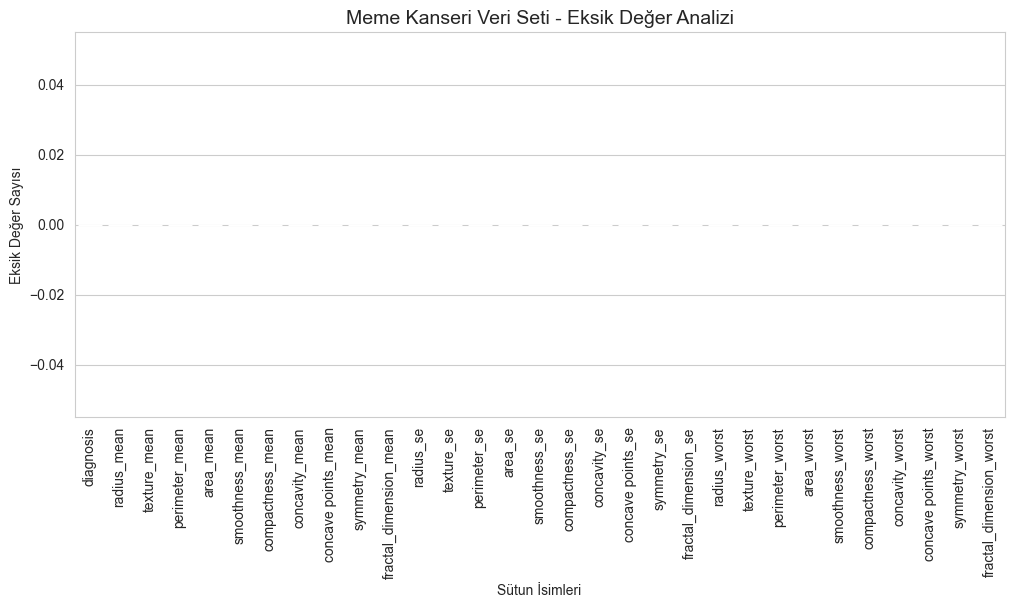

In [8]:
# ============================================================
# 9) EKSİK DEĞER SAYILARI GRAFİĞİ
# ============================================================

missing_counts = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="mako")

# Başlık ve eksen isimlerini Türkçeleştirme
plt.title("Meme Kanseri Veri Seti - Eksik Değer Analizi", fontsize=14)
plt.ylabel("Eksik Değer Sayısı")
plt.xlabel("Sütun İsimleri")

# Sütun sayısı fazla olduğu için isimleri 90 derece döndürüyoruz
plt.xticks(rotation=90)

plt.show()

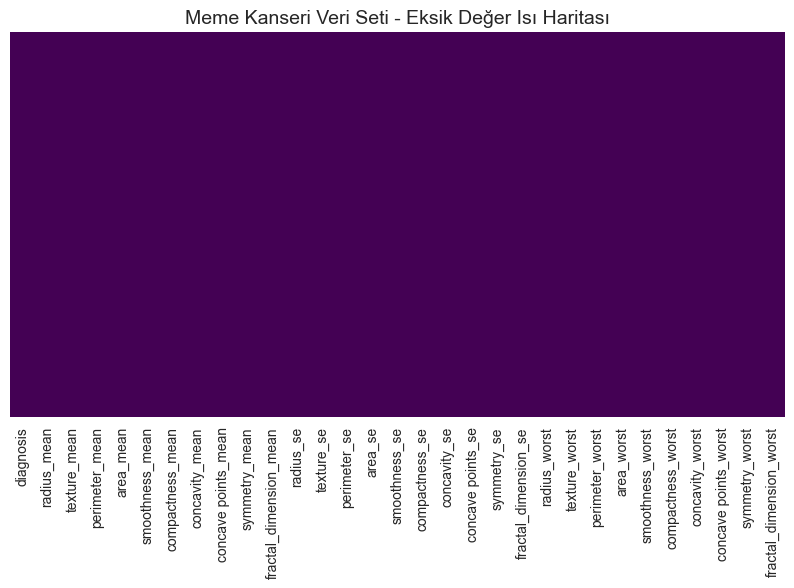

In [9]:
# ============================================================
# 10) EKSİK DEĞER HEATMAP
# Hangi satırlarda eksik değer var, bunu görürüz.
# ============================================================

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Meme Kanseri Veri Seti - Eksik Değer Isı Haritası", fontsize=14)
plt.show()

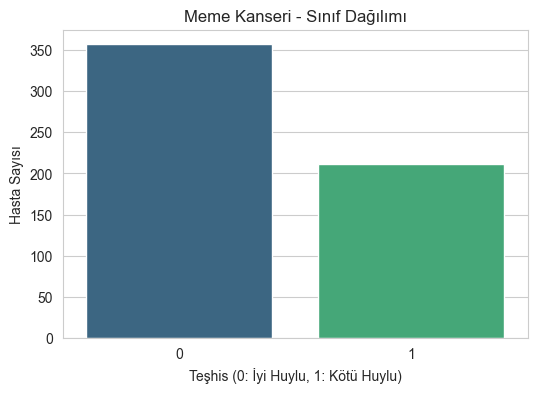

In [10]:
# ============================================================
# 11) SINIF DAĞILIMI
# Veri dengeli mi dengesiz mi bunu görürüz.
# ============================================================

plt.figure(figsize=(6, 4))
# Result yerine diagnosis yazdık
sns.countplot(x="diagnosis", data=df, palette="viridis")

plt.title("Meme Kanseri - Sınıf Dağılımı", fontsize=12)
plt.xlabel("Teşhis (0: İyi Huylu, 1: Kötü Huylu)")
plt.ylabel("Hasta Sayısı")
plt.show()


In [11]:
# ============================================================
# 12) SAYISAL KOLONLARI BUL
# Histogram, boxplot ve diğer sayısal grafikler için kolon seçilir.
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Hedef değişkenimiz olan "diagnosis" sütununu görselleştirme listesinden çıkarıyoruz
if "diagnosis" in numeric_cols:
    numeric_cols.remove("diagnosis")

print("Analiz edilecek sayısal özellikler (Features):")
print(numeric_cols)

Analiz edilecek sayısal özellikler (Features):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


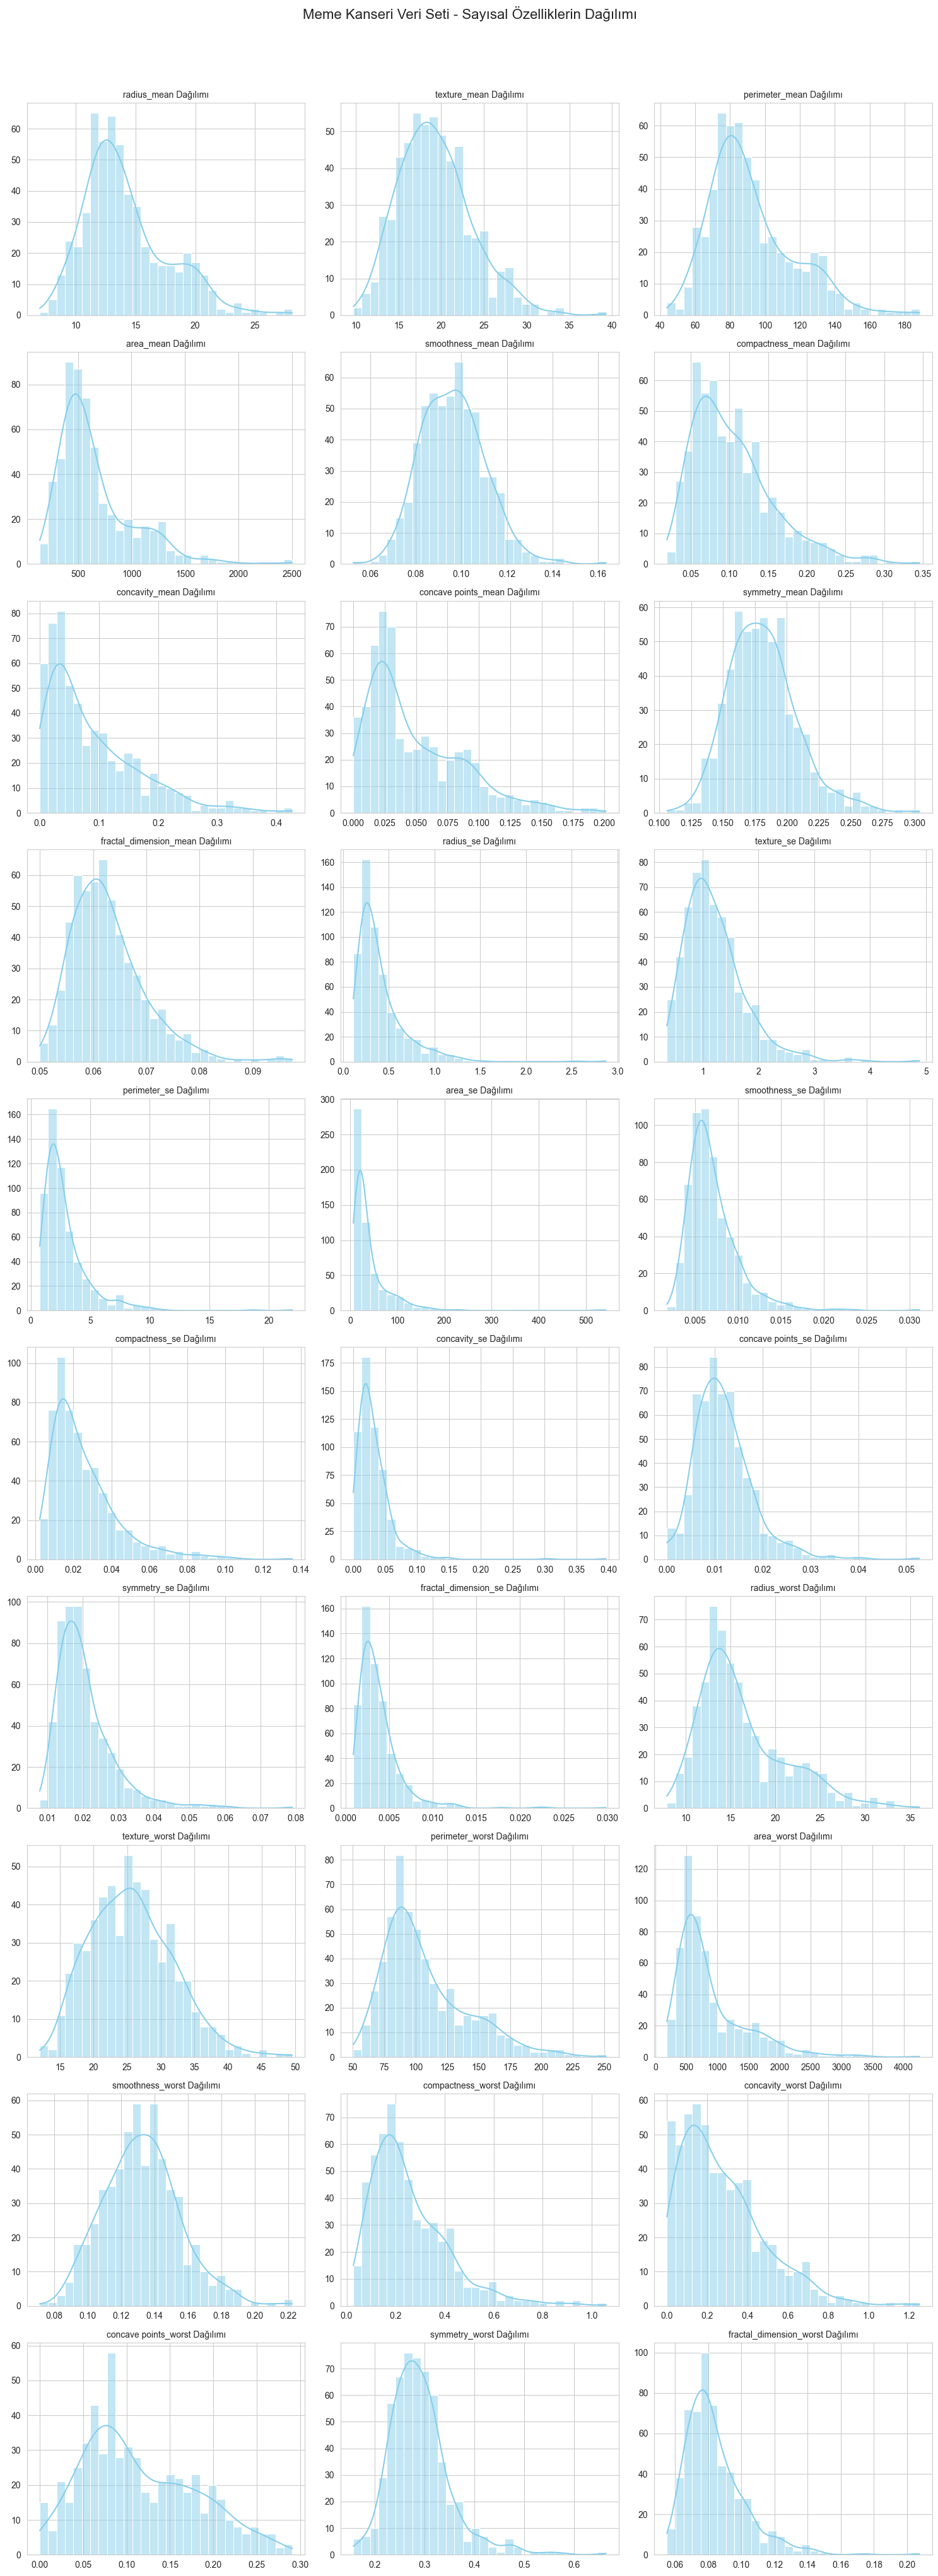

In [12]:
# ============================================================
# 13) HİSTOGRAMLAR
# Her özellik için histogram + KDE çizilir.
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Grafik boyutunu 30 özellik için optimize ediyoruz
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # Veri dağılımını ve yoğunluk eğrisini çiz
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="skyblue")
    plt.title(f"{col} Dağılımı", fontsize=10)
    plt.xlabel("")
    plt.ylabel("")

# Ana başlığı güncelleme
plt.suptitle("Meme Kanseri Veri Seti - Sayısal Özelliklerin Dağılımı", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


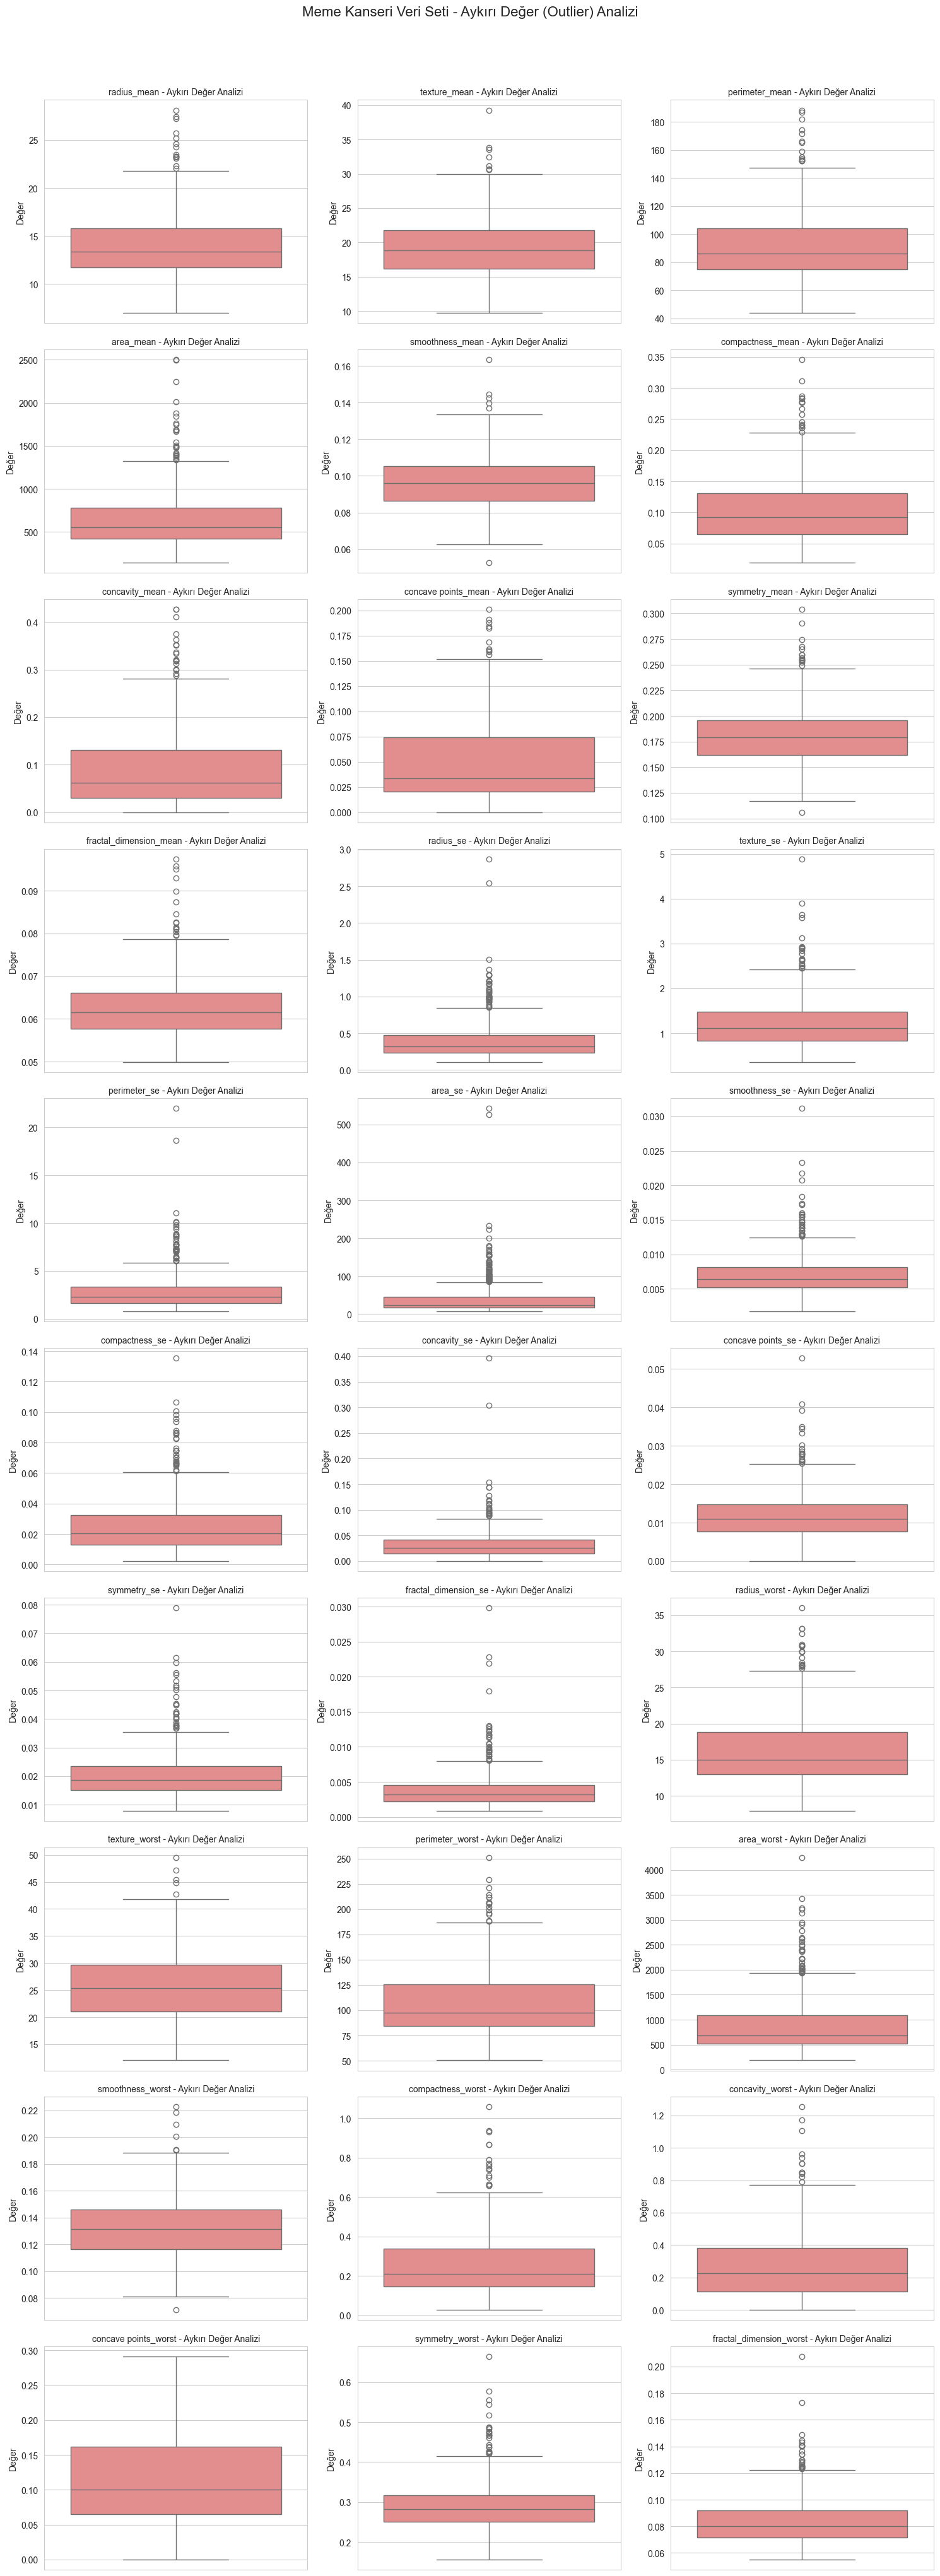

In [13]:
# ============================================================
# 14) BOXPLOTLAR
# Aykırı değerleri görmek için boxplot çizilir.
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Grafik boyutunu özellik sayısına göre ayarlıyoruz
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # Kutu grafiği çizimi
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(f"{col} - Aykırı Değer Analizi", fontsize=10)
    plt.ylabel("Değer")

# Ana başlık
plt.suptitle("Meme Kanseri Veri Seti - Aykırı Değer (Outlier) Analizi", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


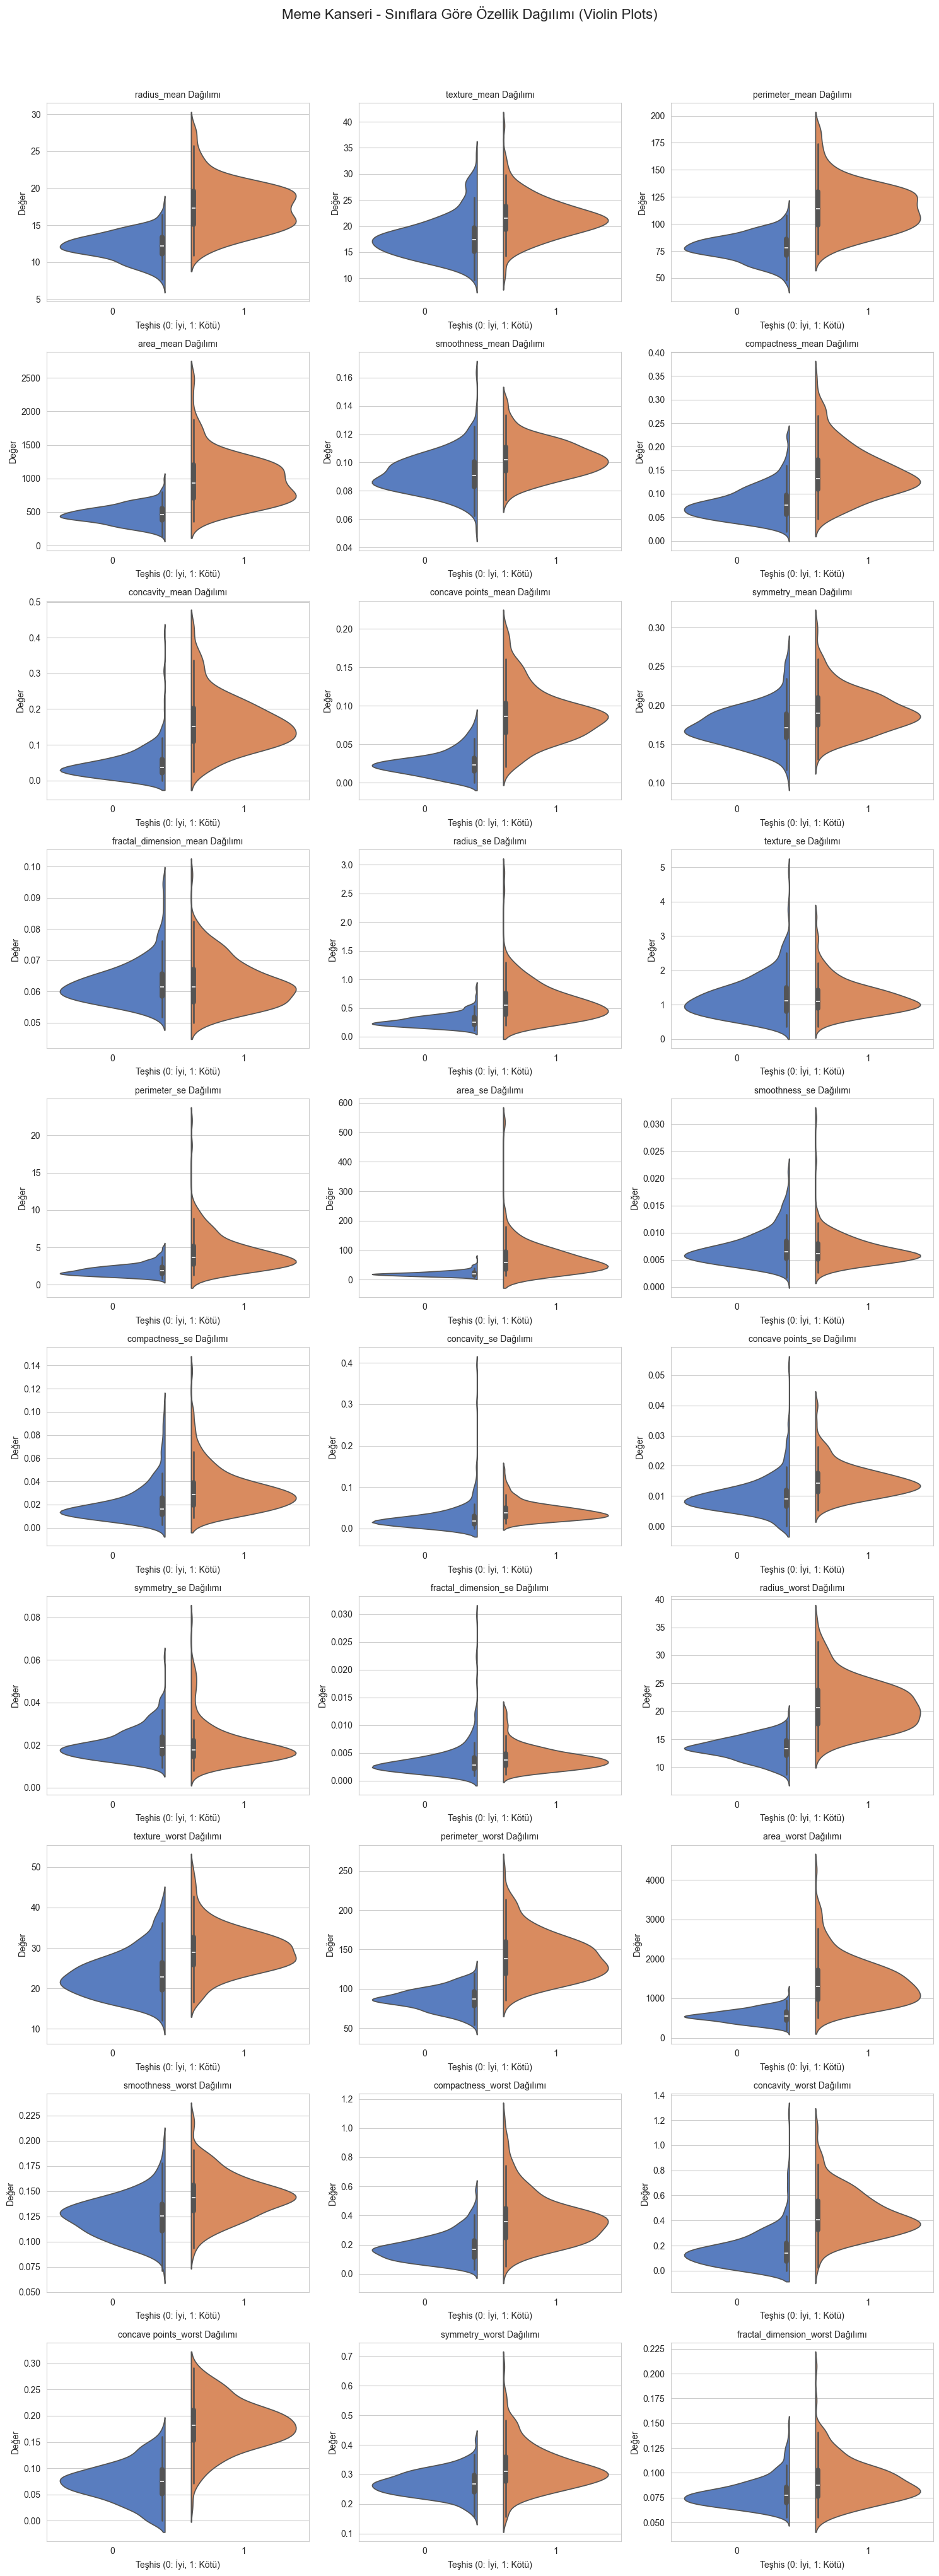

In [14]:
# ============================================================
# 15) SINIFA GÖRE VIOLINPLOT
# Her özellik, sınıf 0 ve sınıf 1 için nasıl dağılıyor diye bakılır.
# ============================================================

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # x="Result" yerine x="diagnosis" olarak güncelledik
    sns.violinplot(x="diagnosis", y=col, data=df, palette="muted", split=True)
    plt.title(f"{col} Dağılımı", fontsize=10)
    plt.xlabel("Teşhis (0: İyi, 1: Kötü)")
    plt.ylabel("Değer")

# Ana başlık güncellemesi
plt.suptitle("Meme Kanseri - Sınıflara Göre Özellik Dağılımı (Violin Plots)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

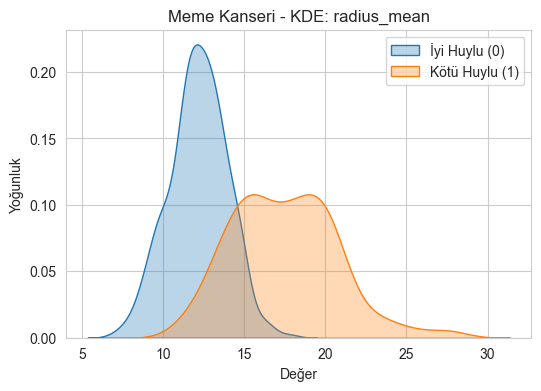

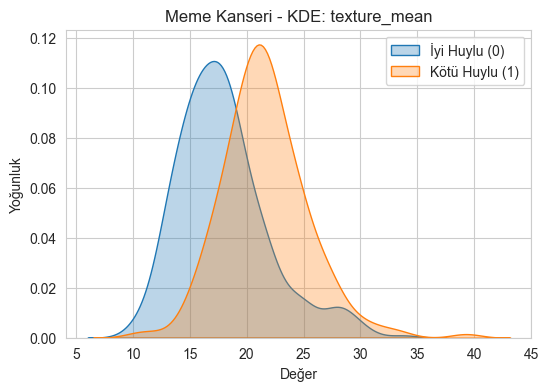

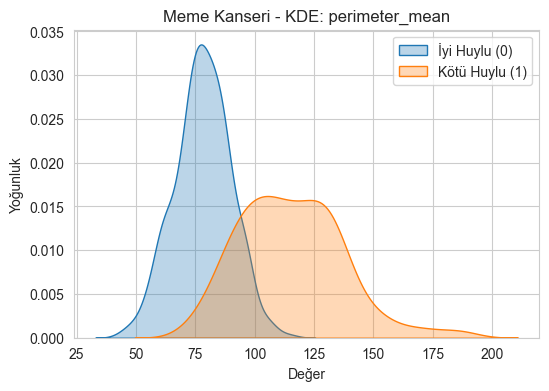

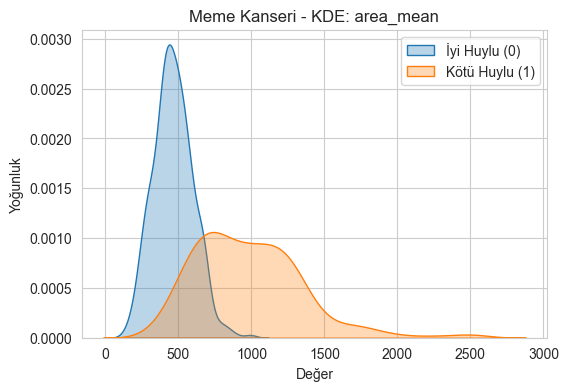

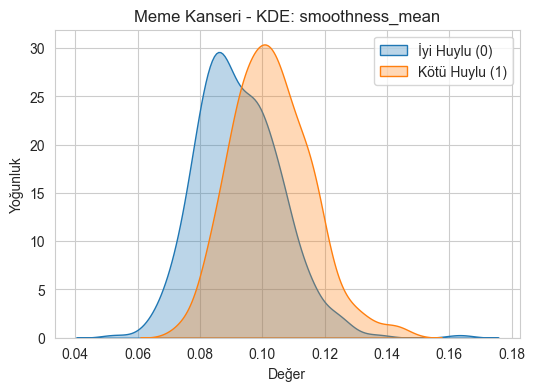

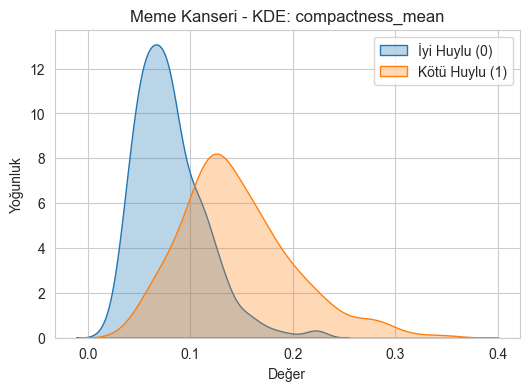

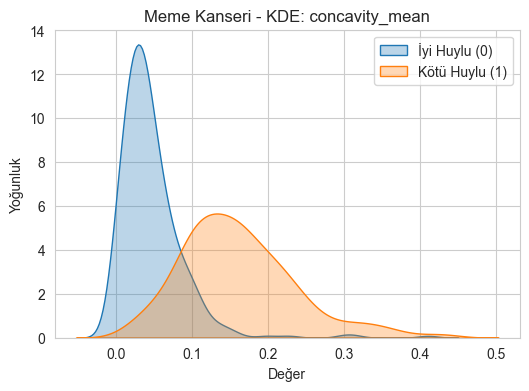

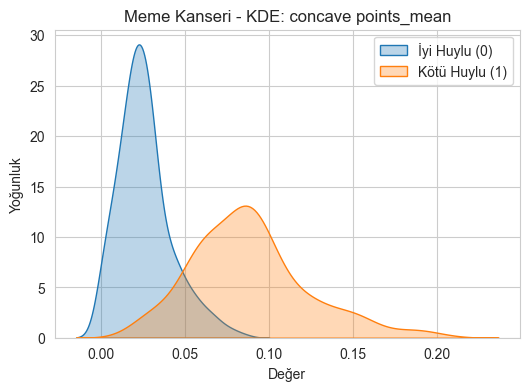

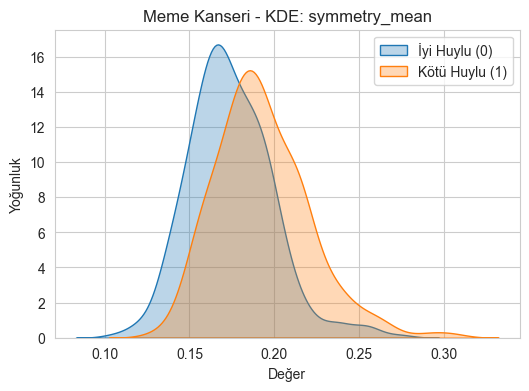

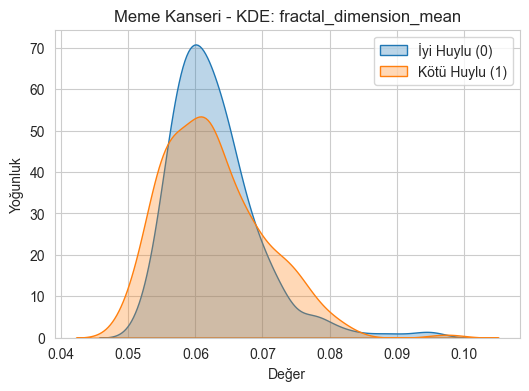

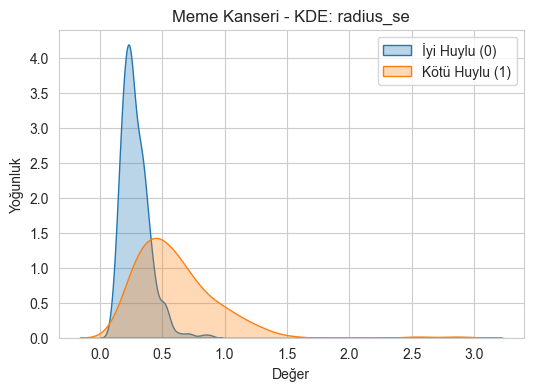

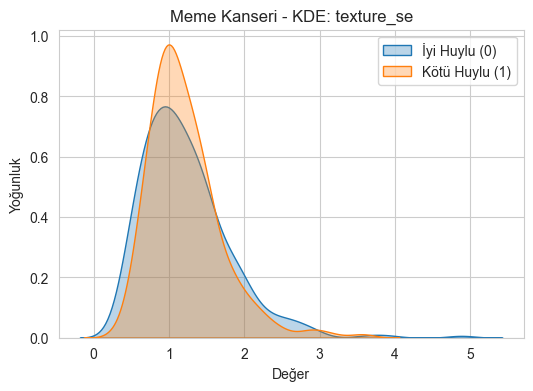

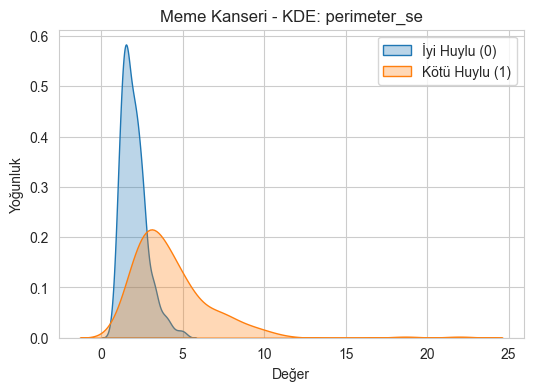

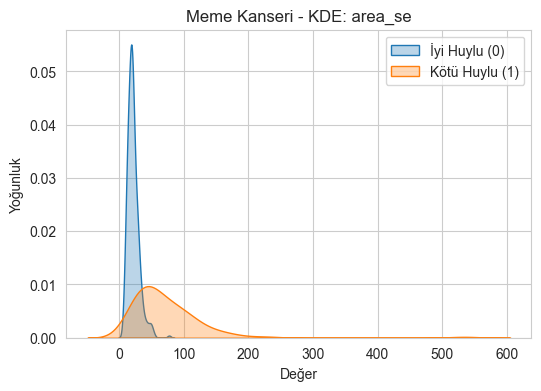

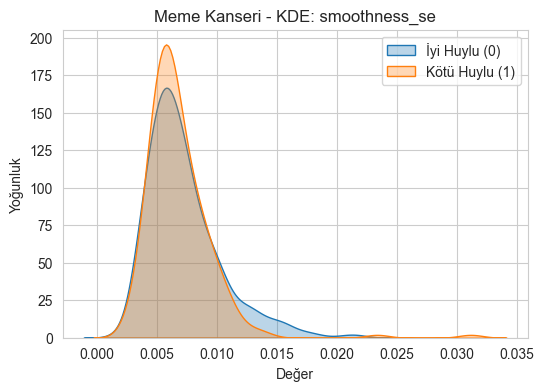

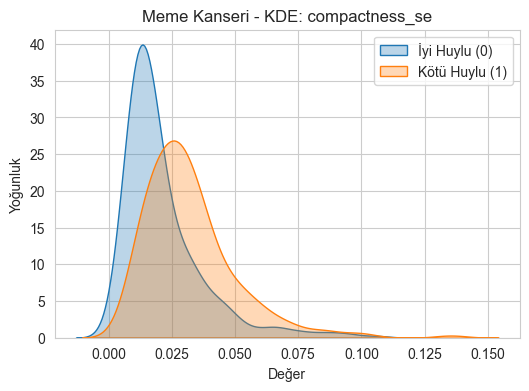

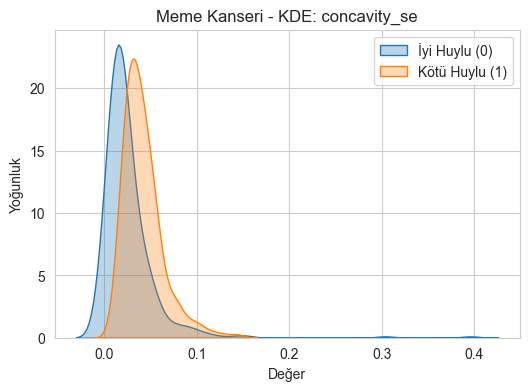

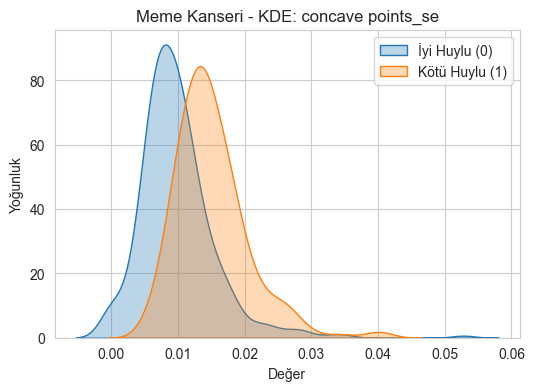

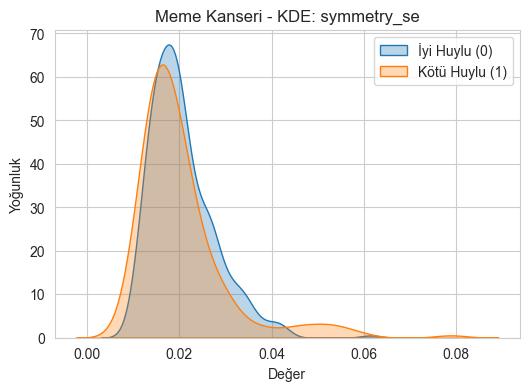

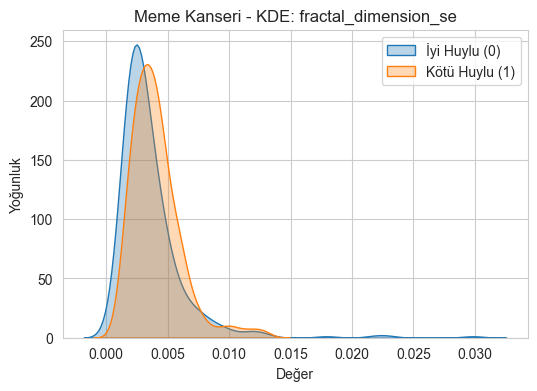

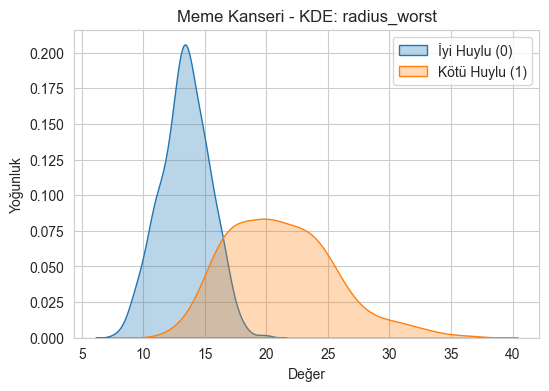

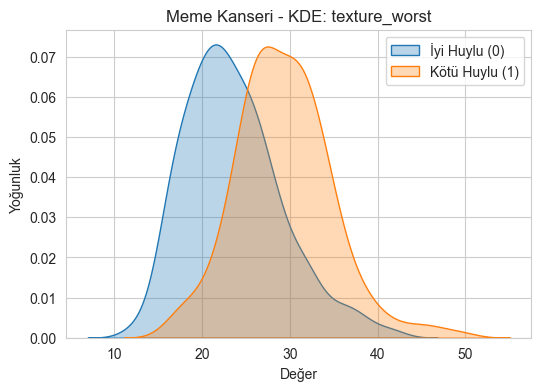

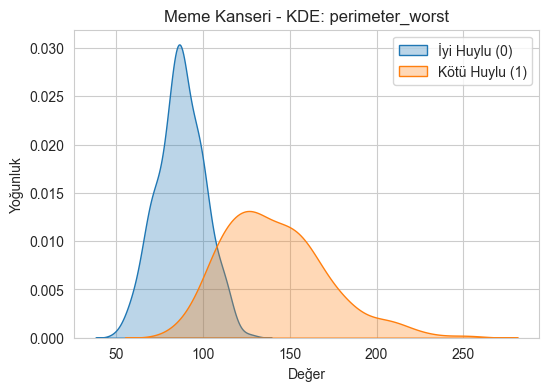

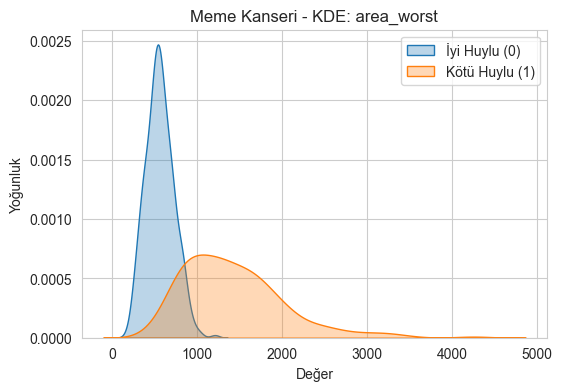

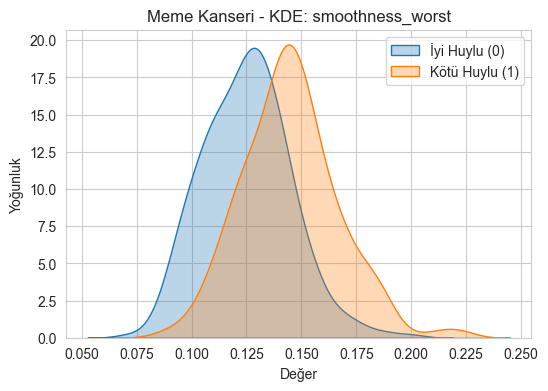

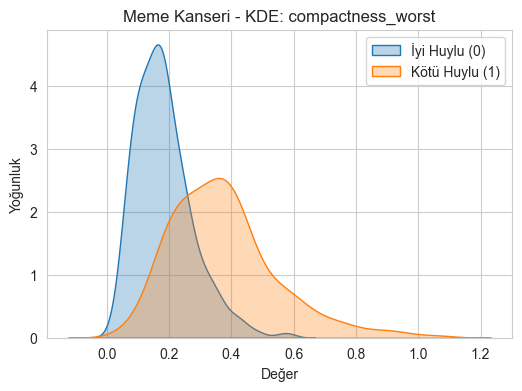

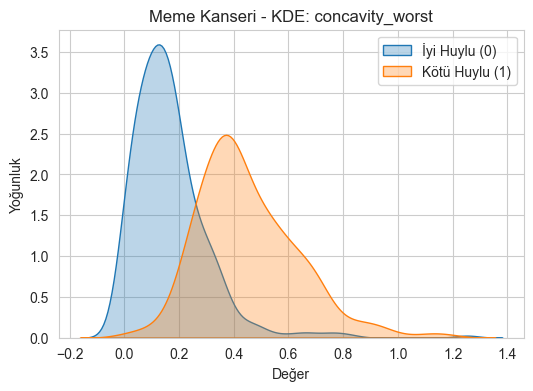

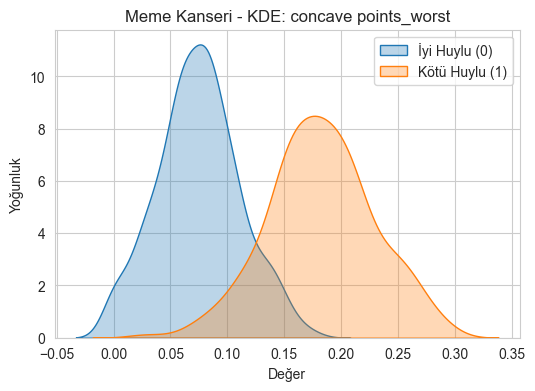

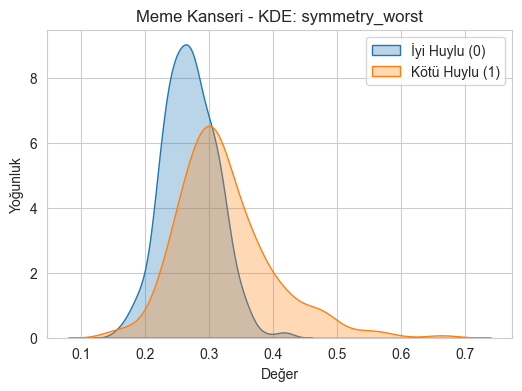

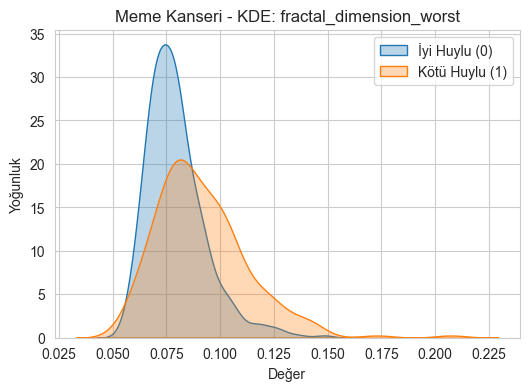

In [15]:
# ============================================================
# 16) KDE GRAFİKLERİ
# Her özellikte sınıflar ne kadar ayrışıyor diye bakmak için kullanılır.
# ============================================================

for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    # "Result" yerine "diagnosis" kullanıyoruz
    for cls in sorted(df["diagnosis"].dropna().unique()):
        subset = df[df["diagnosis"] == cls][col].dropna()
        
        # Sınıf isimlerini daha anlaşılır hale getirelim
        label_text = "Kötü Huylu (1)" if cls == 1 else "İyi Huylu (0)"
        
        if len(subset) > 1:
            sns.kdeplot(subset, label=label_text, fill=True, alpha=0.3)

    plt.title(f"Meme Kanseri - KDE: {col}", fontsize=12)
    plt.xlabel("Değer")
    plt.ylabel("Yoğunluk")
    plt.legend()
    plt.show()


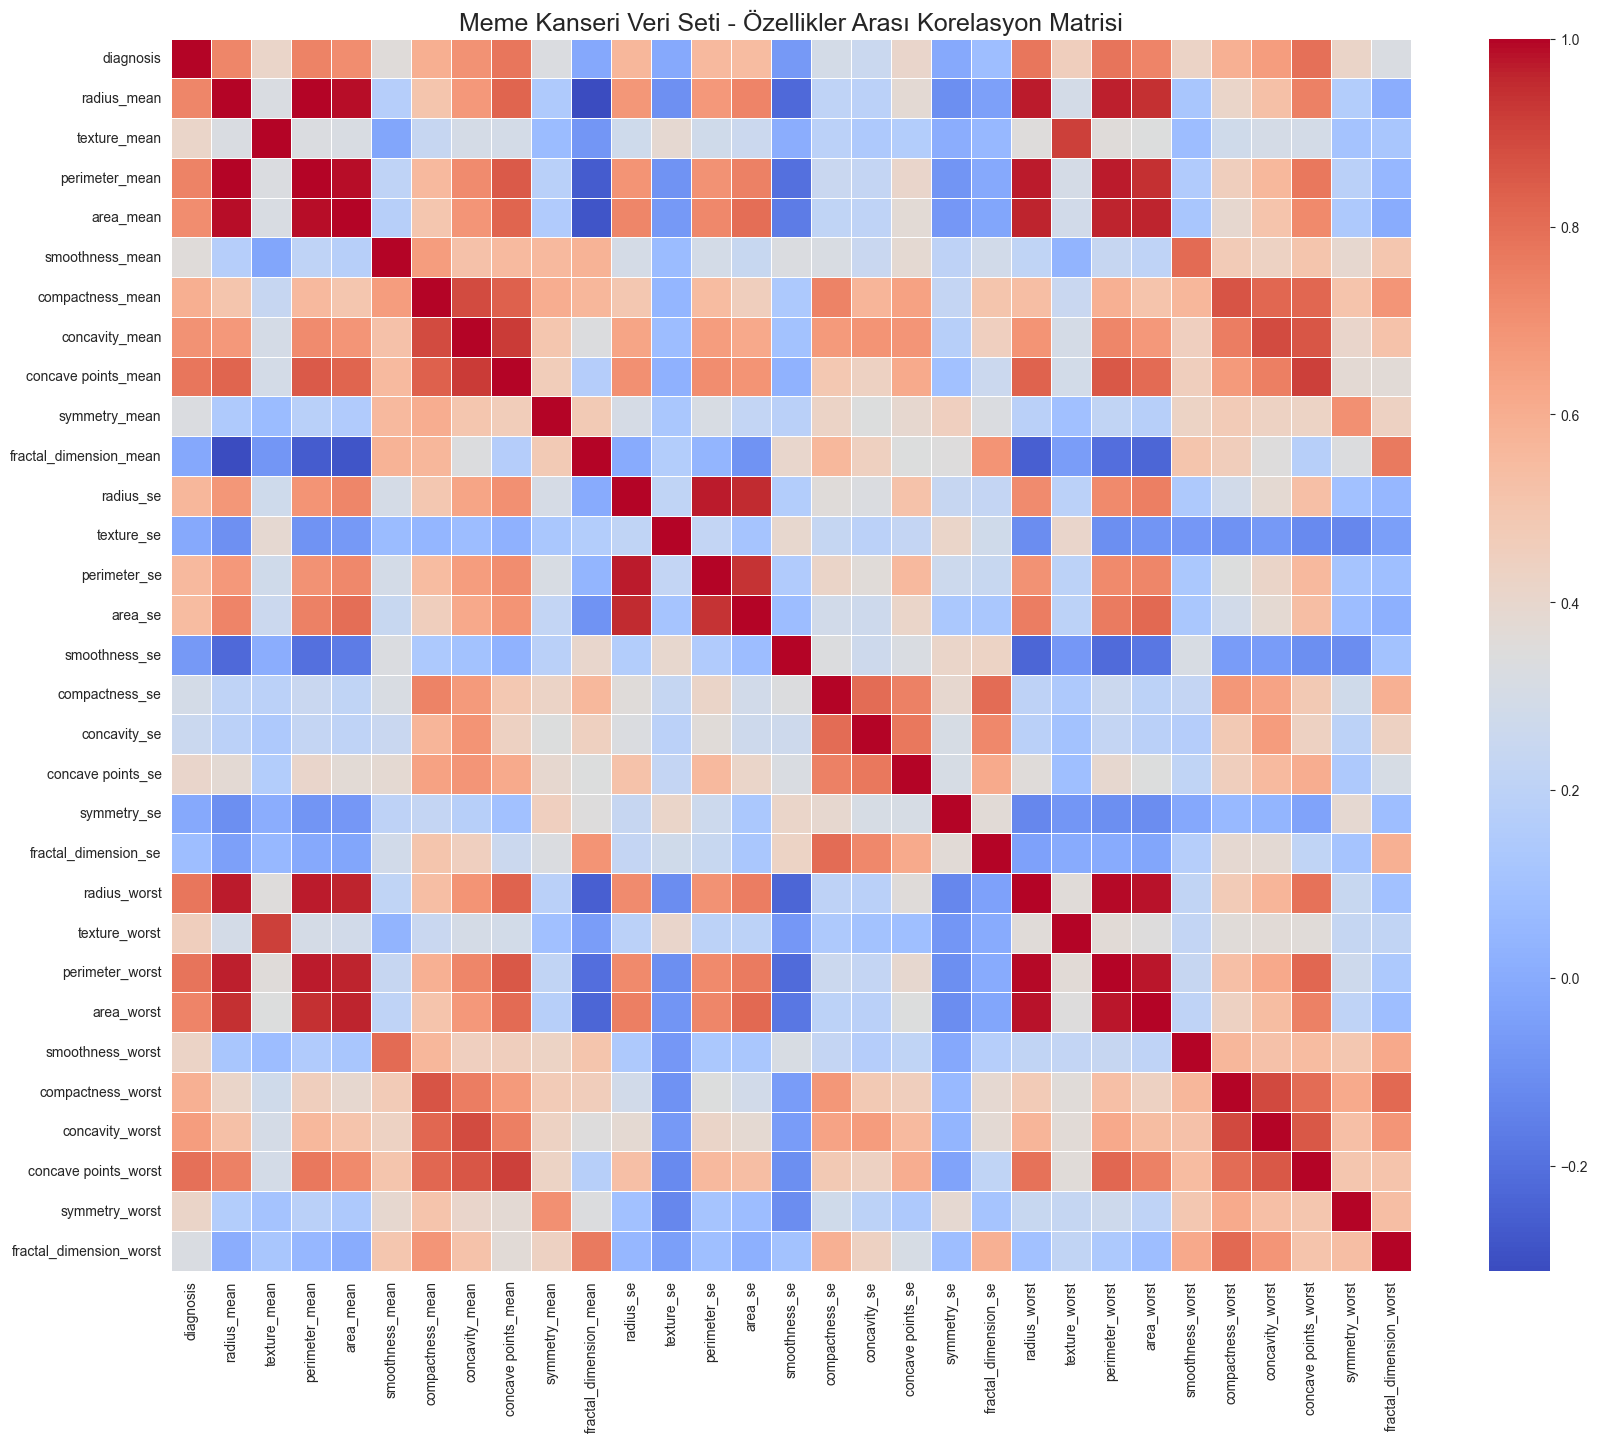

In [16]:
# ============================================================
# 17) KORELASYON ISI HARİTASI
# Özellikler birbirleriyle ne kadar ilişkili görülebilir.
# ============================================================

corr_df = df.select_dtypes(include=[np.number]).copy()

# 30 özellik olduğu için grafik boyutunu büyütüyoruz (Okunabilirlik için)
plt.figure(figsize=(20, 16))

# annot=True yerine False yaptık çünkü 30x30'luk matriste sayılar birbirine girer.
# Eğer sayıları görmek istersen annot=True yapıp font_size'ı küçültebilirsin.
sns.heatmap(corr_df.corr(), annot=False, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Meme Kanseri Veri Seti - Özellikler Arası Korelasyon Matrisi", fontsize=18)
plt.show()


## Şimdi modeli beslemeden önce veri hazırlayacağız

Bu adımda şunları yapacağız:

1. duplicate kayıtları sileceğiz
2. giriş ve hedefi ayıracağız
3. train / validation / test ayıracağız
4. eksik değerleri dolduracağız
5. standardization yapacağız

### Neden standardization?
Çünkü bazı özellikler çok büyük, bazıları çok küçük ölçekte olabilir.  
Bu durum eğitimde bazı özelliklerin baskın hale gelmesine yol açabilir.  
Bu nedenle tüm özellikleri benzer ölçeğe getiririz.


In [17]:
# ============================================================
# 18) VERİ TEMİZLEME
# Duplicate kayıtlar kaldırılır.
# X -> giriş özellikleri
# y -> hedef değişken
# ============================================================

data = df.copy()

# Yinelenen satırları kaldır (Eğer varsa)
data = data.drop_duplicates().reset_index(drop=True)

# "Result" yerine "diagnosis" sütununu ayırıyoruz
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"].astype(int)

print("Temizlenmiş veri boyutu:", data.shape)
print("X (Özellikler) boyutu:", X.shape)
print("y (Hedef) boyutu:", y.shape)

Temizlenmiş veri boyutu: (569, 31)
X (Özellikler) boyutu: (569, 30)
y (Hedef) boyutu: (569,)


In [18]:
# ============================================================
# 19) TRAIN / VALIDATION / TEST SPLIT
# Önce test seti ayrılır.
# Sonra train+val kendi içinde train ve validation olarak ayrılır.
# Stratify kullanıldığı için sınıf oranları korunur.
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y # Sınıf dengesini korumak için (Önemli!)
)

# İkinci bölme: Eğitim setini kendi içinde %80 Eğitim, %20 Doğrulama olarak bölme
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Eğitim seti boyutu (Train):", X_train.shape)
print("Doğrulama seti boyutu (Val)  :", X_val.shape)
print("Test seti boyutu (Test)     :", X_test.shape)

Eğitim seti boyutu (Train): (364, 30)
Doğrulama seti boyutu (Val)  : (91, 30)
Test seti boyutu (Test)     : (114, 30)


## Train / Validation / Test ne işe yarar?

- **Train set**: modelin öğrenmesi için kullanılır
- **Validation set**: eğitim sırasında model seçimi için kullanılır
- **Test set**: en sonda, tamamen bağımsız değerlendirme için kullanılır

Böylece modelin gerçekten genelleyip genellemediğini daha doğru ölçeriz.


In [19]:
# ============================================================
# 20) EKSİK DEĞER TAMAMLAMA
# Median ile doldurma yapılır.
# Median, aykırı değerlere daha dayanıklıdır.
# ============================================================

imputer = SimpleImputer(strategy="median")

# Eğitim setinde öğren ve uygula (fit_transform)
X_train = imputer.fit_transform(X_train)

# Doğrulama ve test setlerinde sadece uygula (transform)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

print("Eksik değer doldurma işlemi başarıyla tamamlandı.")

Eksik değer doldurma işlemi başarıyla tamamlandı.


In [20]:
# ============================================================
# 21) STANDARDIZATION
# Özellikler ortalama 0 ve standart sapma 1 olacak şekilde ölçeklenir.
# ============================================================
from sklearn.preprocessing import StandardScaler
import joblib 
scaler = StandardScaler()

# Eğitim verisi üzerinde istatistikleri öğren ve uygula
X_train = scaler.fit_transform(X_train)

# Doğrulama ve test verilerini aynı parametrelerle dönüştür
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Özellik isimlerini sakla (Daha sonra modelin kararlarını açıklarken kullanacağız)
feature_names = X.columns.tolist()

print("Veri ölçeklendirme tamamlandı.")
print("Analiz edilecek özellik sayısı (Input Size):", len(feature_names))


Veri ölçeklendirme tamamlandı.
Analiz edilecek özellik sayısı (Input Size): 30


In [21]:
# ============================================================
# 22) TORCH TENSOR DÖNÜŞÜMÜ
# PyTorch modeli tensör beklediği için veriler tensöre çevrilir.
# ============================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Hedef değişkenleri (y) tensöre dönüştür ve (N, 1) şeklinde yeniden boyutlandır
# view(-1, 1) işlemi, verinin ağın çıktı formatıyla uyumlu olmasını sağlar.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("Veriler başarıyla PyTorch Tensörlerine dönüştürüldü.")
print("Eğitim seti tensör boyutu:", X_train_tensor.shape)

Veriler başarıyla PyTorch Tensörlerine dönüştürüldü.
Eğitim seti tensör boyutu: torch.Size([364, 30])


## Dataset ve DataLoader neden kullanılır?

PyTorch'ta veriyi doğrudan tümden modele vermek yerine çoğu zaman **batch**'lere böleriz.

### Batch nedir?
Verinin tamamı yerine bir seferde işlenen küçük alt kümedir.

Örneğin:
- veri sayısı = 1000
- batch size = 16

Bu durumda bir epoch içinde yaklaşık `1000 / 16` kadar mini-batch işlenir.

### Epoch nedir?
Tüm eğitim verisinin modele **bir kez tamamen gösterilmesidir**.

Örneğin:
- 100 epoch = tüm train verisinin modele 100 kez gösterilmesi


In [22]:
# ============================================================
# 23) DATASET SINIFI
# Bu sınıf, her çağrıda bir örnek döndürür.
# ============================================================

class TabularDataset(Dataset):
    def __init__(self, X, y):
        """
        Giriş özelliklerini ve hedef etiketleri başlatır.
        """
        self.X = X
        self.y = y

    def __len__(self):
        """
        Veri setindeki toplam örnek (hasta) sayısını döndürür.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Belirli bir indeksteki (idx) veriyi ve etiketi döndürür.
        """
        return self.X[idx], self.y[idx]


In [23]:
# ============================================================
# 24) DATALOADER
# DataLoader, veriyi batch batch sunar.
# shuffle=True train set için önemlidir.
# Çünkü model her epoch'ta veriyi karışık görür.
# ============================================================

batch_size = 16

# Dataset nesnelerini oluştur
train_dataset = TabularDataset(X_train_tensor, y_train_tensor)
val_dataset = TabularDataset(X_val_tensor, y_val_tensor)
test_dataset = TabularDataset(X_test_tensor, y_test_tensor)

# DataLoader'ları tanımla
# shuffle=True: Modelin verilerin sırasını ezberlememesi için eğitim setini her epoch'ta karıştırır.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoader'lar hazır. Her bir yığın (batch) {batch_size} örnek içeriyor.")

DataLoader'lar hazır. Her bir yığın (batch) 16 örnek içeriyor.


# Model Tasarımı

Şimdi farklı yapay sinir ağı mimarileri kuracağız.

## Ne tür farklar deneyeceğiz?
- 1 gizli katmanlı küçük ağ
- 2 katmanlı klasik ağ
- 3 katmanlı orta derinlikte ağ
- 4 katmanlı daha büyük ağ
- 5 katmanlı ağ
- 6 katmanlı ağ

## Neden farklı ağlar deniyoruz?
Çünkü öğrenci şu ilişkiyi görmeli:
- katman sayısı artınca temsil gücü artabilir
- ama aşırı derinlik overfitting yapabilir
- optimizer seçimi sonucu değiştirebilir
- aktivasyon fonksiyonu öğrenme davranışını etkileyebilir
- dropout overfitting'i azaltabilir


In [24]:
# ============================================================
# 25) AKTİVASYON SEÇİCİ
# Kullanılacak aktivasyon fonksiyonunu string ile seçiyoruz.
# ============================================================

def get_activation(name):
    """
    Girilen isme göre uygun PyTorch aktivasyon fonksiyonunu döndürür.
    """
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "elu":
        return nn.ELU()
    elif name == "leakyrelu":
        return nn.LeakyReLU()
    else:
        # Geçersiz bir aktivasyon ismi girilirse hata fırlatır
        raise ValueError(f"Desteklenmeyen aktivasyon fonksiyonu: {name}")

In [25]:
# ============================================================
# 26) ANN MODELİ
# Bu model tam bağlı katmanlardan oluşur.
# hidden_layers listesi, kaç katman ve her katmanda kaç nöron olacağını belirler.
# Örnek:
# [16] -> 1 gizli katman
# [32, 16] -> 2 gizli katman
# [64, 32, 16] -> 3 gizli katman
# ============================================================

class PyTorchANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu", dropout_rate=0.0, batch_norm=False):
        """
        Model mimarisini kuran yapıcı fonksiyon.
        input_dim: Giriş özellik sayısı (Meme kanseri için 30)
        hidden_layers: Gizli katmanlardaki nöron sayılarını içeren liste
        """
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Gizli katmanları dinamik olarak oluştur
        for units in hidden_layers:
            # 1) Tam bağlı katman (Fully Connected)
            layers.append(nn.Linear(prev_dim, units))

            # 2) Batch Normalization (Eğitimi stabilize eder ve hızlandırır)
            if batch_norm:
                layers.append(nn.BatchNorm1d(units))

            # 3) Aktivasyon Fonksiyonu
            layers.append(get_activation(activation))

            # 4) Dropout (Aşırı öğrenmeyi -overfitting- engeller)
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

            # Bir sonraki katman için giriş boyutunu güncelle
            prev_dim = units

        # Son katman: İkili sınıflandırma (0 veya 1) için tek bir çıktı üretir
        layers.append(nn.Linear(prev_dim, 1))

        # Tüm katmanları ardışık bir yapıya bağla
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """
        Verinin ağ içerisindeki ileri yönlü akışını yönetir.
        """
        return self.network(x)


## Neden son katmanda tek nöron var?

Bu problem iki sınıflı olduğu için modelin tek bir sayı üretmesi yeterlidir.

Bu sayı:
- doğrudan olasılık değil
- önce **logit** olarak üretilir

Daha sonra:
- loss hesabında `BCEWithLogitsLoss`
- tahmin aşamasında sigmoid

kullanılır.


In [26]:
# ============================================================
# 27) OPTIMIZER SEÇİCİ
# Burada farklı optimizer'lar arasında seçim yapılır.
# ============================================================

def get_optimizer(model, optimizer_name="adam", lr=1e-3):
    """
    Model parametreleri ve öğrenme oranına (learning rate) göre optimizer döndürür.
    """
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        # Adam: Hızlı yakınsama ve uyarlanabilir öğrenme oranı için popüler seçim.
        return optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        # SGD: Klasik Gradyan İnişi. Momentum ile daha kararlı hale getirilmiştir.
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        # RMSprop: Genellikle tekrarlayan sinir ağlarında (RNN) tercih edilir.
        return optim.RMSprop(model.parameters(), lr=lr)
    else:
        # Desteklenmeyen bir isim girilirse hata mesajı verir.
        raise ValueError(f"Desteklenmeyen optimizer ismi: {optimizer_name}")

## Optimizer nedir?

Optimizer, modelin ağırlıklarını nasıl güncelleyeceğini belirler.

### Adam
- çoğu problemde iyi başlangıç seçeneğidir
- pratikte çok yaygın

### SGD
- klasik optimizer
- bazen daha kararlı genelleme verebilir
- ama ayar isteme ihtimali daha fazladır

### RMSprop
- bazı problemlerde iyi sonuç verebilir
- adaptif öğrenme oranı kullanır


In [27]:
def sigmoid_numpy(x):
    """Lojistik sigmoid fonksiyonu (Logitleri olasılığa çevirir)."""
    return 1 / (1 + np.exp(-x))

def run_one_epoch(model, loader, criterion, optimizer=None):
    """
    Modeli bir epoch boyunca çalıştırır. 
    optimizer varsa 'Eğitim', yoksa 'Değerlendirme' modundadır.
    """
    # Modu belirle: Eğitim mi yoksa test/doğrulama mı?
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_logits = []
    all_targets = []

    for batch_X, batch_y in loader:
        # Verileri işlem birimine (CPU/GPU) taşı
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Eğitim modundaysa gradyanları temizle
        if is_train:
            optimizer.zero_grad()

        # İleri Yayılım (Forward Pass)
        logits = model(batch_X)

        # Kayıp (Loss) Hesaplama
        loss = criterion(logits, batch_y)

        # Geri Yayılım ve Parametre Güncelleme (Sadece eğitimde)
        if is_train:
            loss.backward()
            optimizer.step()

        # Kayıp miktarını kümülatif olarak ekle
        total_loss += loss.item() * batch_X.size(0)

        # Tahminleri ve gerçek değerleri sakla
        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(batch_y.detach().cpu().numpy())

    # Ortalama kaybı hesapla
    total_loss /= len(loader.dataset)

    # Sonuçları tek bir dizi haline getir
    all_logits = np.vstack(all_logits).ravel()
    all_targets = np.vstack(all_targets).ravel()

    # Olasılık değerlerini al
    all_probs = sigmoid_numpy(all_logits)
    # Varsayılan 0.5 eşik değeri ile sınıflandırma yap
    all_preds = (all_probs >= 0.5).astype(int)

    # Performans metriklerini hesapla
    metrics = {
        "loss": total_loss,
        "accuracy": accuracy_score(all_targets, all_preds),
        "precision": precision_score(all_targets, all_preds, zero_division=0),
        "recall": recall_score(all_targets, all_preds, zero_division=0),
        "f1": f1_score(all_targets, all_preds, zero_division=0),
        "auc": roc_auc_score(all_targets, all_probs)
    }

    return metrics, all_targets, all_probs

def find_best_threshold(y_true, y_prob):
    """
    Hassasiyet (Precision) ve Duyarlılık (Recall) dengesine göre 
    F1 skorunu maksimize eden en iyi eşik değerini bulur.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    if len(thresholds) == 0:
        return 0.5

    # F1 skorlarını hesapla (Sıfıra bölünme hatasını engellemek için 1e-8 eklendi)
    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    
    # En yüksek F1 skoruna sahip indeksi bul
    best_idx = np.argmax(f1_scores)
    return float(thresholds[best_idx])

## Training loop nasıl çalışıyor?

Bir epoch içinde şu adımlar olur:

1. train verisi batch batch alınır
2. model ileri yayılım yapar
3. loss hesaplanır
4. geri yayılım yapılır
5. optimizer ağırlıkları günceller
6. epoch bitince train metrikleri hesaplanır
7. validation set ile model ölçülür

Bu döngü epoch sayısı kadar tekrar eder.


In [28]:
def train_model(config, train_loader, val_loader, input_dim, class_pos_weight=None):
    # 1) Modeli yapılandırma ayarlarına göre oluştur ve cihaza (GPU/CPU) taşı
    model = PyTorchANN(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        activation=config["activation"],
        dropout_rate=config["dropout_rate"],
        batch_norm=config["batch_norm"]
    ).to(device)

    # 2) Belirlenen optimizer algoritmasını ve öğrenme oranını tanımla
    optimizer = get_optimizer(model, config["optimizer"], config["learning_rate"])

    # 3) Kayıp (Loss) fonksiyonunu belirle
    # Sınıf dengesizliği varsa pozitif sınıfa (Kanser) daha fazla ağırlık verilebilir
    if class_pos_weight is not None:
        pos_weight_tensor = torch.tensor([class_pos_weight], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    else:
        criterion = nn.BCEWithLogitsLoss()

    # 4) Eğitim ve doğrulama metriklerini saklamak için geçmiş (history) sözlüğü
    history = {
        "train_loss": [], "train_accuracy": [], "train_precision": [],
        "train_recall": [], "train_f1": [], "train_auc": [],
        "val_loss": [], "val_accuracy": [], "val_precision": [],
        "val_recall": [], "val_f1": [], "val_auc": [],
        "lr": []
    }

    # 5) Erken durdurma (Early Stopping) ve en iyi modeli saklama değişkenleri
    best_state = None
    best_val_loss = np.inf
    patience_counter = 0

    # 6) Epoch Döngüsü (Eğitim süreci)
    for epoch in range(config["epochs"]):
        # Eğitim adımını çalıştır
        train_metrics, _, _ = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)

        # Doğrulama (Validation) adımını çalıştır
        val_metrics, val_targets, val_probs = run_one_epoch(model, val_loader, criterion, optimizer=None)

        # Metrikleri geçmişe kaydet
        for key in train_metrics:
            history[f"train_{key}"].append(train_metrics[key])
        for key in val_metrics:
            history[f"val_{key}"].append(val_metrics[key])
        
        history["lr"].append(optimizer.param_groups[0]["lr"])

        # 7) En iyi modeli (Best Model) kaydetme mantığı
        # Eğer doğrulama kaybı (val_loss) iyileşirse ağırlıkları sakla
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Belirli aralıklarla eğitim durumunu ekrana yazdır
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:4d} | "
                f"Train Loss: {train_metrics['loss']:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val F1: {val_metrics['f1']:.4f} | "
                f"Val AUC: {val_metrics['auc']:.4f}"
            )

        # 8) Erken Durdurma (Early Stopping) kontrolü
        if patience_counter >= config["patience"]:
            print(f"Erken Durdurma (Early Stopping) tetiklendi. Epoch: {epoch+1}")
            break

    # Eğitimi bitir ve en iyi ağırlıkları modele geri yükle
    if best_state is not None:
        model.load_state_dict(best_state)

    # 9) Doğrulama seti üzerinde F1 skorunu maksimize eden en iyi eşik değerini bul
    _, val_targets, val_probs = run_one_epoch(model, val_loader, criterion, optimizer=None)
    best_threshold = find_best_threshold(val_targets, val_probs)

    return model, history, best_threshold

In [30]:
# ============================================================
# 30) TEST DEĞERLENDİRME
# Eğitilen modeli test setinde ölçer.
# ============================================================

def evaluate_on_test(model, test_loader, threshold=0.5):
    """
    Modeli test verisi üzerinde çalıştırır ve detaylı metrik sonuçlarını döner.
    """
    # Kayıp fonksiyonunu tanımla
    criterion = nn.BCEWithLogitsLoss()

    # Modeli test verisi üzerinde çalıştır (Eğitim kapalı)
    _, y_true, y_prob = run_one_epoch(model, test_loader, criterion, optimizer=None)
    
    # Tahminleri belirlenen eşik değerine (threshold) göre 0 veya 1'e çevir
    y_pred = (y_prob >= threshold).astype(int)

    # Performans metriklerini hesapla
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

    return results, y_true, y_prob, y_pred


In [31]:
# ============================================================
# 31) EĞİTİM GRAFİKLERİ
# Bu fonksiyonlar train ve validation eğrilerini çizer.
# ============================================================

def plot_training_metric(history, train_key, val_key, title, ylabel):
    """Belirli bir metriğin eğitim ve doğrulama süreçlerini grafikleştirir."""
    plt.figure(figsize=(7, 4))
    plt.plot(history[train_key], label=f"Eğitim (Train) - {train_key.split('_')[1]}")
    plt.plot(history[val_key], label=f"Doğrulama (Val) - {val_key.split('_')[1]}")
    
    plt.title(title, fontsize=12)
    plt.xlabel("Epok (Epoch)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_learning_rate(history):
    """Eğitim boyunca öğrenme oranının (Learning Rate) değişimini gösterir."""
    plt.figure(figsize=(7, 4))
    plt.plot(history["lr"], color='orange', linewidth=2)
    plt.title("Öğrenme Oranı Değişimi (Learning Rate)", fontsize=12)
    plt.xlabel("Epok (Epoch)")
    plt.ylabel("LR Değeri")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_all_training_curves(history):
    """Tüm performans grafiklerini tek bir komutla çizer."""
    plot_training_metric(history, "train_loss", "val_loss", "Kayıp Eğrisi (Loss Curve)", "Hata / Kayıp")
    plot_training_metric(history, "train_accuracy", "val_accuracy", "Doğruluk Eğrisi (Accuracy Curve)", "Doğruluk Oranı")
    plot_training_metric(history, "train_precision", "val_precision", "Kesinlik Eğrisi (Precision Curve)", "Kesinlik")
    plot_training_metric(history, "train_recall", "val_recall", "Duyarlılık Eğrisi (Recall Curve)", "Duyarlılık")
    plot_training_metric(history, "train_f1", "val_f1", "F1 Skor Eğrisi (F1 Curve)", "F1 Skoru")
    plot_training_metric(history, "train_auc", "val_auc", "AUC Eğrisi (ROC-AUC Curve)", "AUC Skoru")
    plot_learning_rate(history)

In [32]:
# ============================================================
# 32) TEST GRAFİKLERİ VE ANALİZ FONKSİYONLARI
# Modelin test seti üzerindeki başarısını detaylı görselleştirir.
# ============================================================

def plot_confusion_counts(y_true, y_pred):
    """Karmaşıklık Matrisi (Confusion Matrix) - Ham sayılar."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Karmaşıklık Matrisi (Sayısal)")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.show()

def plot_confusion_normalized(y_true, y_pred):
    """Normalize edilmiş Karmaşıklık Matrisi - Oranlar."""
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Greens")
    plt.title("Normalize Edilmiş Karmaşıklık Matrisi")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.show()

def plot_roc_curve_graph(y_true, y_prob):
    """ROC Eğrisi - Modelin ayırt edici gücünü gösterir."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("ROC Eğrisi")
    plt.xlabel("Yanlış Pozitif Oranı (FPR)")
    plt.ylabel("Doğru Pozitif Oranı (TPR)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pr_curve_graph(y_true, y_prob):
    """Kesinlik-Duyarlılık (Precision-Recall) Eğrisi."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, color="purple", label=f"PR AUC = {pr_auc:.4f}")
    plt.title("Kesinlik-Duyarlılık (Precision-Recall) Eğrisi")
    plt.xlabel("Duyarlılık (Recall)")
    plt.ylabel("Kesinlik (Precision)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_threshold_curves(y_true, y_prob):
    """Eşik Değeri (Threshold) Analizi - Metriklerin değişimi."""
    thresholds = np.linspace(0.01, 0.99, 99)
    precisions, recalls, f1s, accs = [], [], [], []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        accs.append(accuracy_score(y_true, y_pred))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions, label="Kesinlik (Precision)")
    plt.plot(thresholds, recalls, label="Duyarlılık (Recall)")
    plt.plot(thresholds, f1s, label="F1 Skoru")
    plt.plot(thresholds, accs, label="Doğruluk (Accuracy)")
    plt.title("Eşik Değeri (Threshold) Analizi")
    plt.xlabel("Eşik Değeri")
    plt.ylabel("Metrik Puanı")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_probability_histogram(y_true, y_prob):
    """Tahmin Olasılık Dağılımı - Modelin ne kadar emin olduğunu gösterir."""
    plt.figure(figsize=(7, 4))
    plt.hist(y_prob[y_true == 0], bins=20, alpha=0.5, label="Gerçek: İyi Huylu (0)", color="blue")
    plt.hist(y_prob[y_true == 1], bins=20, alpha=0.5, label="Gerçek: Kötü Huylu (1)", color="red")
    plt.title("Tahmin Olasılık Dağılımı")
    plt.xlabel("Tahmin Edilen Olasılık")
    plt.ylabel("Örnek Sayısı")
    plt.legend()
    plt.show()

def plot_calibration(y_true, y_prob):
    """Kalibrasyon Eğrisi - Tahmin edilen olasılıkların gerçeklik payı."""
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.figure(figsize=(6, 4))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Mükemmel Kalibrasyon")
    plt.title("Kalibrasyon Eğrisi")
    plt.xlabel("Ortalama Tahmin Edilen Olasılık")
    plt.ylabel("Gözlemlenen Frekans")
    plt.legend()
    plt.show()

def plot_classification_report_heatmap(y_true, y_pred):
    """Sınıflandırma Raporu Isı Haritası."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    keep_rows = [idx for idx in report_df.index if idx not in ["accuracy", "macro avg", "weighted avg"]]
    keep_cols = [c for c in ["precision", "recall", "f1-score"] if c in report_df.columns]
    plt.figure(figsize=(6, 4))
    sns.heatmap(report_df.loc[keep_rows, keep_cols], annot=True, cmap="YlOrBr", fmt=".4f")
    plt.title("Sınıflandırma Raporu (Isı Haritası)")
    plt.show()

In [33]:
# ============================================================
# 33) FEATURE IMPORTANCE - İLK KATMAN AĞIRLIKLARI
# Öğrenci için basit ama öğretici bir feature importance yaklaşımı.
# ============================================================

def plot_first_layer_weight_importance(model, feature_names, top_n=20):
    first_linear = None

    # Ağdaki ilk tam bağlı (Linear) katmanı bul
    for layer in model.network:
        if isinstance(layer, nn.Linear):
            first_linear = layer
            break

    if first_linear is None:
        print("Uyarı: Modelde Linear katman bulunamadı.")
        return None

    # Ağırlıkları al ve mutlak değerlerinin ortalamasını hesapla
    weights = first_linear.weight.detach().cpu().numpy()
    importance = np.mean(np.abs(weights), axis=0)

    # Özellikleri önem sırasına göre veri çerçevesine (DataFrame) aktar
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False).head(top_n)

    # Görselleştirme (Özellik isimleri sığsın diye boyutu 10x6 yaptık)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="magma")
    
    plt.title("Meme Kanseri - Özellik Önem Dereceleri (İlk Katman Ağırlıkları)", fontsize=14)
    plt.xlabel("Önem Derecesi (Ortalama Mutlak Ağırlık)")
    plt.ylabel("Tıbbi Özellikler (Features)")
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return imp_df

In [34]:
def model_predict_proba_numpy(model, X_np):
    """NumPy dizisi alıp olasılık (probability) döndüren yardımcı fonksiyon."""
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(X_np, dtype=torch.float32).to(device)
        logits = model(X_tensor).cpu().numpy().ravel()
        probs = 1 / (1 + np.exp(-logits))

    return probs

def permutation_importance_for_pytorch(model, X_np, y_np, feature_names, threshold=0.5, top_n=20):
    # 1) Temel (Baseline) performansı hesapla
    baseline_prob = model_predict_proba_numpy(model, X_np)
    baseline_pred = (baseline_prob >= threshold).astype(int)
    baseline_f1 = f1_score(y_np, baseline_pred, zero_division=0)

    importances = []

    # 2) Her bir özelliği sırayla boz ve performanstaki düşüşü ölç
    for i, feat in enumerate(feature_names):
        X_perm = X_np.copy()
        np.random.shuffle(X_perm[:, i]) # Sadece ilgili sütunu karıştır

        perm_prob = model_predict_proba_numpy(model, X_perm)
        perm_pred = (perm_prob >= threshold).astype(int)
        perm_f1 = f1_score(y_np, perm_pred, zero_division=0)

        # Temel F1 skoru ile yeni F1 skoru arasındaki farkı bul
        drop_in_f1 = baseline_f1 - perm_f1
        importances.append((feat, drop_in_f1))

    # Sonuçları DataFrame'e aktar ve en önemlilerini seç
    imp_df = pd.DataFrame(importances, columns=["feature", "importance"])
    imp_df = imp_df.sort_values("importance", ascending=False).head(top_n)

    # Görselleştirme
    plt.figure(figsize=(10, 6)) # Özellik isimleri sığsın diye boyutu 10x6 yaptık
    sns.barplot(data=imp_df, x="importance", y="feature", palette="rocket")
    
    plt.title("Meme Kanseri - Permütasyon Önem Derecesi (F1 Düşüşü)", fontsize=14)
    plt.xlabel("Önem Derecesi (F1 Skorundaki Düşüş)")
    plt.ylabel("Tıbbi Özellikler (Features)")
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return imp_df

In [35]:
def plot_integrated_gradients_global(model, X_reference_np, X_samples_np, feature_names, sample_count=50):
    """
    Modelin genel olarak hangi özelliklere odaklandığını (Global Importance) gösterir.
    """
    model.eval()
    ig = IntegratedGradients(model)

    sample_count = min(sample_count, len(X_samples_np))
    # Rastgele hasta örnekleri seç
    chosen_idx = np.random.choice(len(X_samples_np), sample_count, replace=False)

    # Referans (Baseline) noktası olarak verilerin medyanını kullanıyoruz
    baseline = torch.tensor(np.median(X_reference_np, axis=0), dtype=torch.float32).unsqueeze(0).to(device)
    attr_list = []

    for idx in chosen_idx:
        sample = torch.tensor(X_samples_np[idx], dtype=torch.float32).unsqueeze(0).to(device)
        attributions, _ = ig.attribute(sample, baselines=baseline, return_convergence_delta=True)
        attr_list.append(np.abs(attributions.detach().cpu().numpy().ravel()))

    # Seçilen örneklerin ortalama önem derecesini hesapla
    mean_attr = np.mean(np.vstack(attr_list), axis=0)

    ig_df = pd.DataFrame({
        "feature": feature_names,
        "importance": mean_attr
    }).sort_values("importance", ascending=False)

    # Görselleştirme
    plt.figure(figsize=(10, 6))
    sns.barplot(data=ig_df.head(20), x="importance", y="feature", palette="viridis")
    plt.title("Meme Kanseri - Integrated Gradients (Genel Önem Derecesi)", fontsize=14)
    plt.xlabel("Önem Derecesi (Attribution Score)")
    plt.ylabel("Tıbbi Özellikler")
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return ig_df


def plot_integrated_gradients_local(model, X_reference_np, X_samples_np, feature_names, sample_index=0):
    """
    Sadece BELİRLİ BİR HASTA (sample_index) için modelin neden kanser veya 
    iyi huylu teşhisi koyduğunu açıklar (Local Explanation).
    """
    model.eval()
    ig = IntegratedGradients(model)

    baseline = torch.tensor(np.median(X_reference_np, axis=0), dtype=torch.float32).unsqueeze(0).to(device)
    sample = torch.tensor(X_samples_np[sample_index], dtype=torch.float32).unsqueeze(0).to(device)

    attributions, _ = ig.attribute(sample, baselines=baseline, return_convergence_delta=True)
    attr = attributions.detach().cpu().numpy().ravel()

    local_df = pd.DataFrame({
        "feature": feature_names,
        "importance": attr
    }).sort_values("importance", ascending=False)

    # Görselleştirme
    plt.figure(figsize=(10, 6))
    # Pozitif ve negatif etkileri renklerle ayır (Kırmızı: Kansere iten, Mavi: İyi huyluya iten)
    colors = ['red' if x > 0 else 'blue' for x in local_df["importance"]]
    sns.barplot(data=local_df, x="importance", y="feature", palette=colors)
    
    plt.title(f"Hasta Bazlı Yerel Açıklama (Lokal XAI) - Örnek İndeks: {sample_index}", fontsize=14)
    plt.xlabel("Karara Etki Puanı (Pozitif: Kansere Eğilim, Negatif: İyi Huyluya Eğilim)")
    plt.ylabel("Hastanın Tıbbi Sonuçları")
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return local_df

In [36]:
# ============================================================
# 36) GİZLİ UZAY GÖRSELLEŞTİRMESİ
# Son gizli katman özelliklerini PCA ve t-SNE ile görselleştirir.
# ============================================================

def get_penultimate_features(model, X_np):
    """
    Modelin son katmanından (çıktı) bir önceki katmanındaki özellikleri (features) çeker.
    Bu, modelin veriyi sınıflandırmadan hemen önce nasıl anladığını gösterir.
    """
    model.eval()

    # Son katman (Linear(..., 1)) hariç tüm katmanları al
    layers = list(model.network.children())[:-1]
    feature_extractor = nn.Sequential(*layers).to(device)

    with torch.no_grad():
        X_tensor = torch.tensor(X_np, dtype=torch.float32).to(device)
        feats = feature_extractor(X_tensor).cpu().numpy()

    return feats


def plot_hidden_space_pca_tsne(model, X_np, y_np):
    """
    Yüksek boyutlu gizli uzay verilerini PCA ve t-SNE algoritmaları ile 
    2 boyuta indirgeyerek görselleştirir.
    """
    # Gizli özellikleri (Hidden Features) çıkar
    hidden_features = get_penultimate_features(model, X_np)

    # ---------------------------------------------------------
    # 1. PCA (Principal Component Analysis)
    # Doğrusal (Linear) boyut indirgeme tekniği. Verideki en büyük varyansı bulur.
    # ---------------------------------------------------------
    pca = PCA(n_components=2, random_state=42)
    pca_features = pca.fit_transform(hidden_features)

    plt.figure(figsize=(8, 6))
    # 0 ve 1 sınıflarını (İyi/Kötü huylu) renklerle ayırıyoruz
    sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=y_np, palette="coolwarm", alpha=0.7)
    plt.title("Meme Kanseri - Gizli Uzay PCA Dağılımı", fontsize=14)
    plt.xlabel("Birinci Temel Bileşen (PC1)")
    plt.ylabel("İkinci Temel Bileşen (PC2)")
    plt.legend(title="Teşhis (0: İyi, 1: Kötü)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # ---------------------------------------------------------
    # 2. t-SNE (t-Distributed Stochastic Neighbor Embedding)
    # Doğrusal olmayan (Non-linear) boyut indirgeme tekniği. 
    # Benzer verileri uzayda birbirine yakın kümeler (clusters) halinde gösterir.
    # ---------------------------------------------------------
    # Hesaplama maliyetini düşürmek ve grafiği okunaklı kılmak için örneklem (sample) alıyoruz
    sample_n = min(300, len(hidden_features))
    idx = np.random.choice(len(hidden_features), sample_n, replace=False)
    hidden_sample = hidden_features[idx]
    y_sample = np.array(y_np)[idx]

    tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
    tsne_features = tsne.fit_transform(hidden_sample)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=tsne_features[:, 0], y=tsne_features[:, 1], hue=y_sample, palette="Set1", alpha=0.8)
    plt.title("Meme Kanseri - Gizli Uzay t-SNE Dağılımı", fontsize=14)
    plt.xlabel("t-SNE Boyut 1")
    plt.ylabel("t-SNE Boyut 2")
    plt.legend(title="Teşhis (0: İyi, 1: Kötü)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# Daha Fazla Model Deneyi

Burada öğrencinin farkları görebilmesi için daha fazla model tanımladık.

## Neler değişiyor?
- katman sayısı
- nöron sayısı
- aktivasyon
- optimizer
- learning rate
- dropout
- epoch

Böylece hangi tasarımın nasıl davrandığını tablo üzerinden karşılaştırabileceğiz.


In [37]:
configs = [
    # ----------------------------------------------------
    # 1) Çok Küçük Model (Baseline)
    # Amacı: Sistemin çalıştığını teyit etmek ve en alt sınırı belirlemek.
    # ----------------------------------------------------
    {
        "name": "M1_small_relu_adam_100ep",
        "hidden_layers": [8],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "dropout_rate": 0.0,
        "batch_norm": False,
        "epochs": 100,
        "patience": 20
    },

    # ----------------------------------------------------
    # 2) Küçük Ama Biraz Daha Geniş Model
    # Nöron sayısı artırıldı.
    # ----------------------------------------------------
    {
        "name": "M2_small_relu_adam_200ep",
        "hidden_layers": [16],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "dropout_rate": 0.0,
        "batch_norm": False,
        "epochs": 200,
        "patience": 25
    },

    # ----------------------------------------------------
    # 3) Klasik 2 Katmanlı Model (Dengeli Seçim)
    # Batch Normalization ve Dropout eklendi (Overfitting'i önlemek için).
    # ----------------------------------------------------
    {
        "name": "M3_classic_relu_adam_300ep",
        "hidden_layers": [32, 16],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "dropout_rate": 0.10,
        "batch_norm": True,
        "epochs": 300,
        "patience": 30
    },

    # ----------------------------------------------------
    # 4) Tanh Aktivasyonu ve SGD Optimizer
    # Relu+Adam yerine Tanh+SGD ikilisinin performansı test ediliyor.
    # ----------------------------------------------------
    {
        "name": "M4_classic_tanh_sgd_300ep",
        "hidden_layers": [32, 16],
        "activation": "tanh",
        "optimizer": "sgd",
        "learning_rate": 1e-2, # SGD genelde daha yüksek LR ister
        "dropout_rate": 0.10,
        "batch_norm": False,
        "epochs": 300,
        "patience": 30
    },

    # ----------------------------------------------------
    # 5) 3 Katmanlı Model: ELU Aktivasyonu + RMSprop
    # RMSprop genelde dalgalı kayıp yüzeylerinde iyi çalışır.
    # ----------------------------------------------------
    {
        "name": "M5_elu_rmsprop_3layer_400ep",
        "hidden_layers": [64, 32, 16],
        "activation": "elu",
        "optimizer": "rmsprop",
        "learning_rate": 1e-3,
        "dropout_rate": 0.15,
        "batch_norm": True,
        "epochs": 400,
        "patience": 35
    },

    # ----------------------------------------------------
    # 6) 3 Katmanlı Güçlü Model (Relu + Adam)
    # Ağ kapasitesi artırıldı, Öğrenme oranı (LR) biraz düşürüldü.
    # ----------------------------------------------------
    {
        "name": "M6_relu_adam_3layer_500ep",
        "hidden_layers": [64, 32, 16],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "dropout_rate": 0.20,
        "batch_norm": True,
        "epochs": 500,
        "patience": 40
    },

    # ----------------------------------------------------
    # 7) 4 Katmanlı Derin Model
    # Girdi katmanına yakın daha geniş bir nöron ağı (128).
    # ----------------------------------------------------
    {
        "name": "M7_relu_adam_4layer_500ep",
        "hidden_layers": [128, 64, 32, 16],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "dropout_rate": 0.20,
        "batch_norm": True,
        "epochs": 500,
        "patience": 40
    },

    # ----------------------------------------------------
    # 8) 4 Katmanlı Model - LeakyReLU Testi
    # "Dying ReLU" (Nöron ölümü) problemini test etmek için.
    # ----------------------------------------------------
    {
        "name": "M8_leakyrelu_adam_4layer_500ep",
        "hidden_layers": [128, 64, 32, 16],
        "activation": "leakyrelu",
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "dropout_rate": 0.20,
        "batch_norm": True,
        "epochs": 500,
        "patience": 40
    },

    # ----------------------------------------------------
    # 9) 5 Katmanlı Çok Derin Model
    # Meme kanseri verisi (30 özellik) için biraz fazla büyük olabilir,
    # Overfitting'i önlemek için Dropout %25'e çıkarıldı.
    # ----------------------------------------------------
    {
        "name": "M9_relu_adam_5layer_700ep",
        "hidden_layers": [128, 96, 64, 32, 16],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 3e-4,
        "dropout_rate": 0.25,
        "batch_norm": True,
        "epochs": 700,
        "patience": 50
    },

    # ----------------------------------------------------
    # 10) 6 Katmanlı En Derin Model (Heavyweight)
    # Sınırları zorlamak için tasarlanmıştır.
    # ----------------------------------------------------
    {
        "name": "M10_relu_rmsprop_6layer_800ep",
        "hidden_layers": [256, 128, 96, 64, 32, 16],
        "activation": "relu",
        "optimizer": "rmsprop",
        "learning_rate": 3e-4,
        "dropout_rate": 0.25,
        "batch_norm": True,
        "epochs": 800,
        "patience": 60
    }
]

print(f"Toplam test edilecek model konfigürasyonu sayısı: {len(configs)}")

Toplam test edilecek model konfigürasyonu sayısı: 10


## Burada öğrenci neyi gözlemleyebilir?

- küçük model bazen underfitting yapabilir
- çok büyük model bazen overfitting yapabilir
- Adam çoğu zaman hızlı öğrenir
- SGD bazen daha zor ama daha dengeli ilerleyebilir
- dropout arttıkça overfitting azalabilir ama aşırı olursa öğrenme zorlaşabilir
- katman sayısı arttıkça temsil gücü artar ama her zaman performans artmayabilir


In [38]:
# ============================================================
# 38) SINIF AĞIRLIĞI
# Veri dengesizse positive class için loss içinde ek ağırlık tanımlarız.
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Sınıfları belirle (0: İyi Huylu, 1: Kötü Huylu)
classes = np.unique(y_train.values)

# Scikit-learn ile dengeli sınıf ağırlıklarını hesapla
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight_dict = {c: w for c, w in zip(classes, class_weights)}

# PyTorch BCEWithLogitsLoss için özel pozitif sınıf ağırlığı (pos_weight) hesaplama
# Formül: pos_weight = (Negatif Örnek Sayısı) / (Pozitif Örnek Sayısı)
num_neg = np.sum(y_train.values == 0)
num_pos = np.sum(y_train.values == 1)

# Sıfıra bölünme hatasını önlemek için kontrol
pos_weight = num_neg / num_pos if num_pos > 0 else 1.0

print("Scikit-Learn Sınıf Ağırlıkları (Class weights):", class_weight_dict)
print("PyTorch için Pozitif Sınıf Ağırlığı (pos_weight):", round(pos_weight, 4))


Scikit-Learn Sınıf Ağırlıkları (Class weights): {np.int64(0): np.float64(0.7982456140350878), np.int64(1): np.float64(1.338235294117647)}
PyTorch için Pozitif Sınıf Ağırlığı (pos_weight): 1.6765


In [39]:
all_results = []
best_model = None
best_history = None
best_threshold = 0.5
best_config = None
best_test_bundle = None
best_score = -1

# Girdi boyutunu (30 özellik) eğitim setinden alıyoruz
input_dim = X_train.shape[1]

# 10 farklı konfigürasyon üzerinde döngü başlatılıyor
for config in configs:
    print("\n" + "=" * 90)
    print("Çalışan model:", config["name"])
    print("=" * 90)

    # 1) Modeli eğit (Daha önce yazdığımız train_model fonksiyonunu çağırır)
    model, history, threshold = train_model(
        config=config,
        train_loader=train_loader,
        val_loader=val_loader,
        input_dim=input_dim,
        class_pos_weight=pos_weight
    )

    # 2) Eğitilen modeli Test seti üzerinde değerlendir
    test_results, y_true_test, y_prob_test, y_pred_test = evaluate_on_test(
        model=model,
        test_loader=test_loader,
        threshold=threshold
    )

    # 3) Sonuçları bir sözlükte (dictionary) topla
    row = {
        "model_name": config["name"],
        "hidden_layers": str(config["hidden_layers"]),
        "activation": config["activation"],
        "optimizer": config["optimizer"],
        "learning_rate": config["learning_rate"],
        "dropout_rate": config["dropout_rate"],
        "batch_norm": config["batch_norm"],
        "epochs_max": config["epochs"],
        "best_threshold": round(threshold, 4),
        "accuracy": round(test_results["accuracy"], 4),
        "precision": round(test_results["precision"], 4),
        "recall": round(test_results["recall"], 4),
        "f1": round(test_results["f1"], 4),
        "roc_auc": round(test_results["roc_auc"], 4)
    }

    all_results.append(row)
    print("Test sonuçları:", row)

    # 4) Şampiyonu Belirle: Eğer bu modelin F1 skoru şu ana kadarki en iyiyse, bunu "En İyi Model" olarak kaydet
    if test_results["f1"] > best_score:
        best_score = test_results["f1"]
        best_model = model
        best_history = history
        best_threshold = threshold
        best_config = config
        best_test_bundle = (y_true_test, y_prob_test, y_pred_test)

# Tüm sonuçları Pandas DataFrame'e çevir ve F1 skoruna göre azalan şekilde (en iyiden en kötüye) sırala
results_df = pd.DataFrame(all_results).sort_values(by=["f1", "roc_auc"], ascending=False).reset_index(drop=True)

# Liderlik Tablosunu (Leaderboard) ekrana yazdır
display(results_df)


Çalışan model: M1_small_relu_adam_100ep
Epoch    1 | Train Loss: 0.7609 | Val Loss: 0.7238 | Val F1: 0.7470 | Val AUC: 0.9154
Epoch   20 | Train Loss: 0.1394 | Val Loss: 0.1526 | Val F1: 0.9412 | Val AUC: 0.9933
Epoch   40 | Train Loss: 0.0842 | Val Loss: 0.1130 | Val F1: 0.9565 | Val AUC: 0.9959
Epoch   60 | Train Loss: 0.0639 | Val Loss: 0.1060 | Val F1: 0.9706 | Val AUC: 0.9948
Epoch   80 | Train Loss: 0.0507 | Val Loss: 0.1023 | Val F1: 0.9706 | Val AUC: 0.9938
Epoch  100 | Train Loss: 0.0406 | Val Loss: 0.0981 | Val F1: 0.9706 | Val AUC: 0.9938
Test sonuçları: {'model_name': 'M1_small_relu_adam_100ep', 'hidden_layers': '[8]', 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001, 'dropout_rate': 0.0, 'batch_norm': False, 'epochs_max': 100, 'best_threshold': 0.6585, 'accuracy': 0.9737, 'precision': 1.0, 'recall': 0.9286, 'f1': 0.963, 'roc_auc': 0.9954}

Çalışan model: M2_small_relu_adam_200ep
Epoch    1 | Train Loss: 0.7644 | Val Loss: 0.6394 | Val F1: 0.8525 | Val AUC

,model_name,hidden_layers,activation,optimizer,learning_rate,dropout_rate,batch_norm,epochs_max,best_threshold,accuracy,precision,recall,f1,roc_auc
0,M9_relu_adam_5layer_700ep,"[128, 96, 64, 32, 16]",relu,adam,0.0003,0.25,True,700,0.7821,0.9825,1.0000,0.9524,0.9756,0.9990
1,M5_elu_rmsprop_3layer_400ep,"[64, 32, 16]",elu,rmsprop,0.0010,0.15,True,400,0.5411,0.9825,1.0000,0.9524,0.9756,0.9954
2,M1_small_relu_adam_100ep,[8],relu,adam,0.0010,0.00,False,100,0.6585,0.9737,1.0000,0.9286,0.9630,0.9954
3,M3_classic_relu_adam_300ep,"[32, 16]",relu,adam,0.0010,0.10,True,300,0.6169,0.9737,1.0000,0.9286,0.9630,0.9947
4,M8_leakyrelu_adam_4layer_500ep,"[128, 64, 32, 16]",leakyrelu,adam,0.0005,0.20,True,500,0.8061,0.9737,1.0000,0.9286,0.9630,0.9931
5,M7_relu_adam_4layer_500ep,"[128, 64, 32, 16]",relu,adam,0.0005,0.20,True,500,0.3376,0.9649,0.9524,0.9524,0.9524,0.9931
6,M6_relu_adam_3layer_500ep,"[64, 32, 16]",relu,adam,0.0005,0.20,True,500,0.7717,0.9649,1.0000,0.9048,0.9500,0.9937
7,M10_relu_rmsprop_6layer_800ep,"[256, 128, 96, 64, 32, 16]",relu,rmsprop,0.0003,0.25,True,800,0.8496,0.9474,0.9737,0.8810,0.9250,0.9897
8,M2_small_relu_adam_200ep,[16],relu,adam,0.0010,0.00,False,200,0.9797,0.9123,1.0000,0.7619,0.8649,0.9970
9,M4_classic_tanh_sgd_300ep,"[32, 16]",tanh,sgd,0.0100,0.10,False,300,0.9465,0.9035,1.0000,0.7381,0.8493,0.9974


🏆 Şampiyon Model (En İyi Konfigürasyon): M5_elu_rmsprop_3layer_400ep
Eğitim metrikleri çiziliyor, lütfen bekleyiniz...



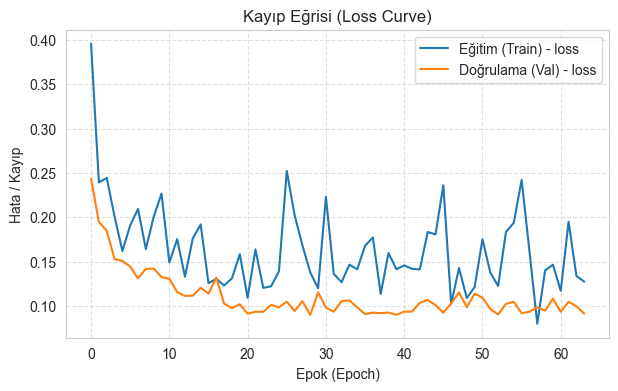

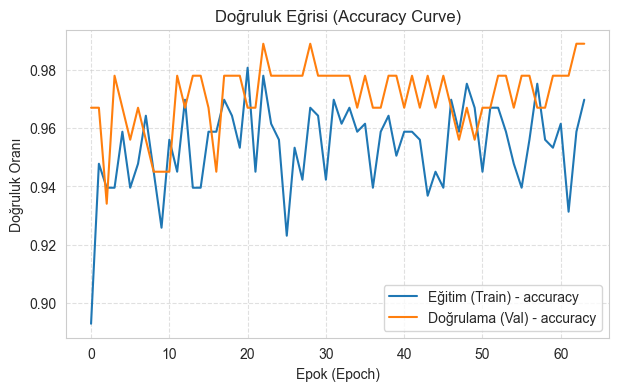

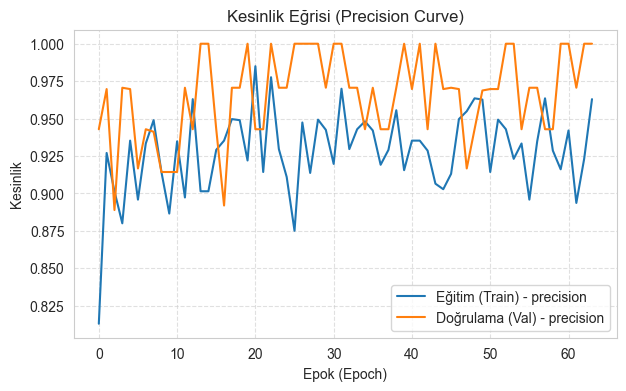

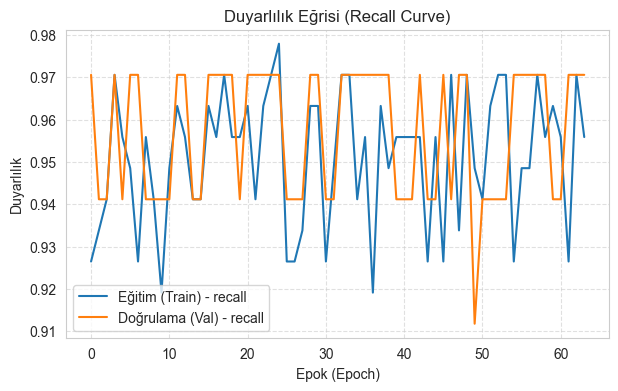

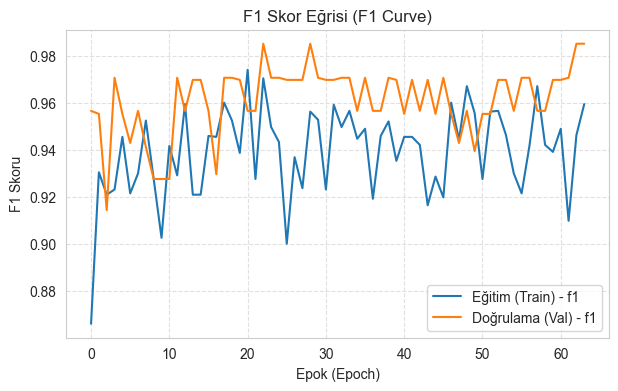

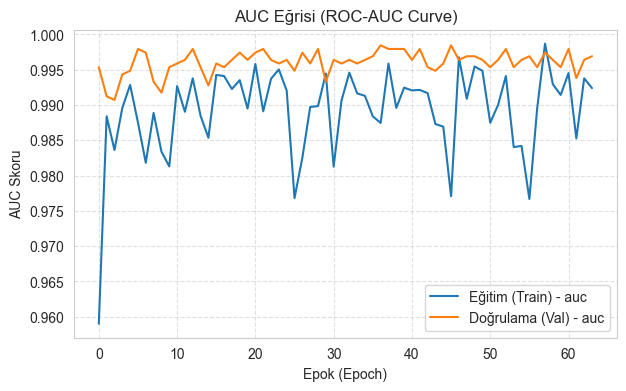

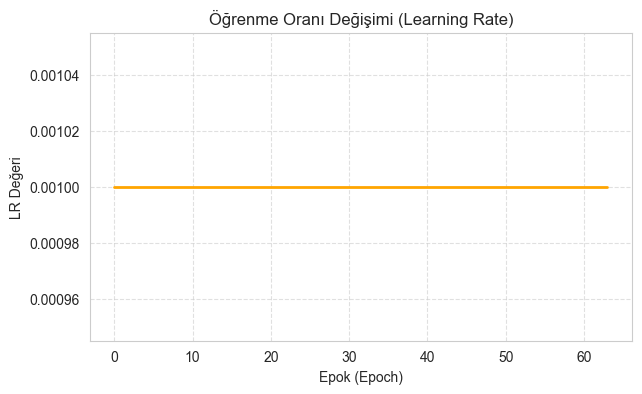

In [40]:
# ============================================================
# 40) EN İYİ MODELİN EĞİTİM GRAFİKLERİ (BEST MODEL TRAINING CURVES)
# 10 farklı konfigürasyon arasından birinci olan modelin 
# eğitim süreci boyunca gösterdiği performansı görselleştirir.
# Loss, Accuracy, Precision, Recall, F1, AUC ve LR değişimleri çizilir.
# ============================================================

print("🏆 Şampiyon Model (En İyi Konfigürasyon):", best_config["name"])
print("Eğitim metrikleri çiziliyor, lütfen bekleyiniz...\n")

# Daha önce tanımladığımız fonksiyonu çağırarak tüm grafikleri tek seferde ekrana yansıt
plot_all_training_curves(best_history)


🌟 ŞAMPİYON MODEL - TEST SETİ SONUÇLARI 🌟
---------------------------------------------
Accuracy (Doğruluk)  : 0.9825
Precision (Kesinlik) : 1.0000
Recall (Duyarlılık)  : 0.9524
F1 Skoru             : 0.9756
ROC AUC Skoru        : 0.9954
---------------------------------------------

Performans Grafikleri Oluşturuluyor...



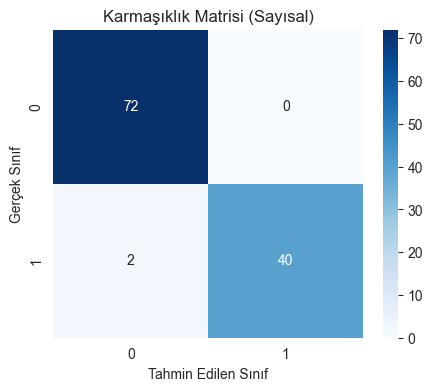

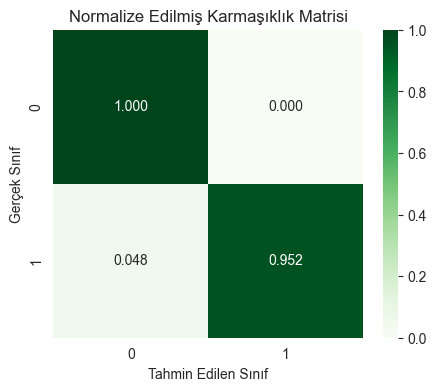

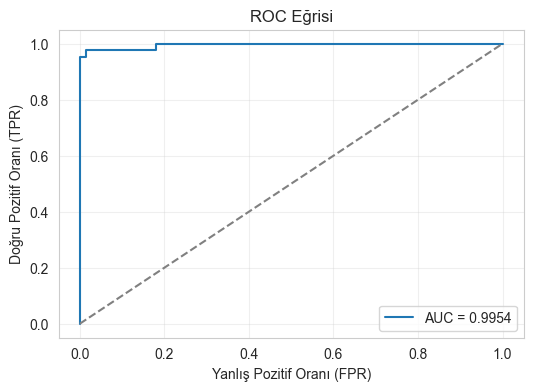

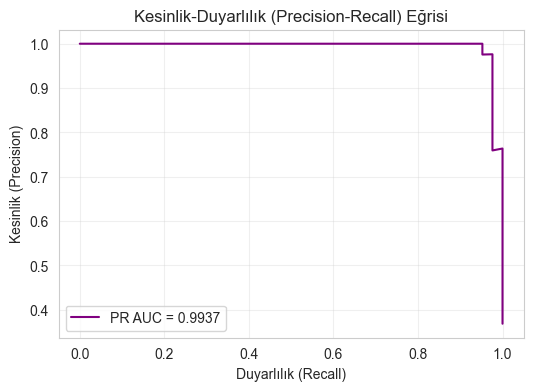

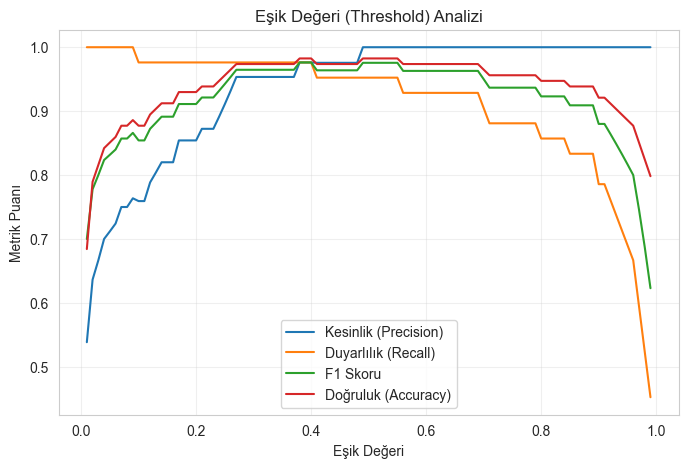

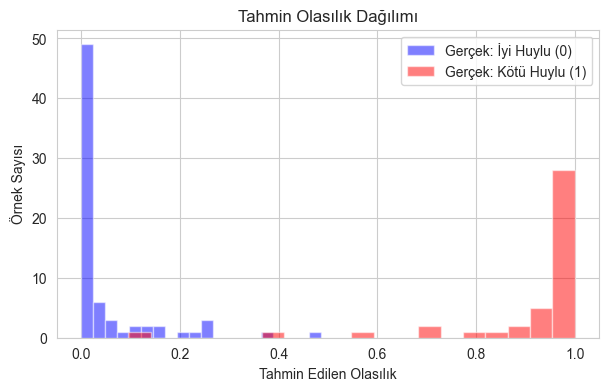

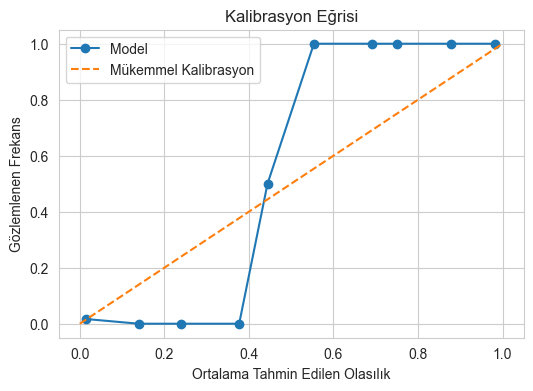

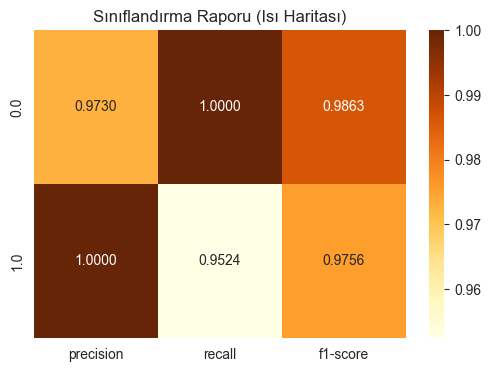


📋 Detaylı Sınıflandırma Raporu (Classification Report):

              precision    recall  f1-score   support

         0.0     0.9730    1.0000    0.9863        72
         1.0     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



In [41]:
# ============================================================
# 41) EN İYİ MODELİN TEST GRAFİKLERİ VE NİHAİ PERFORMANSI
# Şampiyon modelin hiç görmediği test verisi üzerindeki 
# gerçek başarımını detaylı grafikler ve metriklerle raporlar.
# ============================================================

# Test verilerini paketten (bundle) çıkar
y_true_test, y_prob_test, y_pred_test = best_test_bundle

print("🌟 ŞAMPİYON MODEL - TEST SETİ SONUÇLARI 🌟")
print("-" * 45)
print(f"Accuracy (Doğruluk)  : {accuracy_score(y_true_test, y_pred_test):.4f}")
print(f"Precision (Kesinlik) : {precision_score(y_true_test, y_pred_test, zero_division=0):.4f}")
print(f"Recall (Duyarlılık)  : {recall_score(y_true_test, y_pred_test, zero_division=0):.4f}")
print(f"F1 Skoru             : {f1_score(y_true_test, y_pred_test, zero_division=0):.4f}")
print(f"ROC AUC Skoru        : {roc_auc_score(y_true_test, y_prob_test):.4f}")
print("-" * 45)

print("\nPerformans Grafikleri Oluşturuluyor...\n")

# Hazırladığımız tüm test görselleştirmelerini sırayla ekrana bas
plot_confusion_counts(y_true_test, y_pred_test)
plot_confusion_normalized(y_true_test, y_pred_test)
plot_roc_curve_graph(y_true_test, y_prob_test)
plot_pr_curve_graph(y_true_test, y_prob_test)
plot_threshold_curves(y_true_test, y_prob_test)
plot_probability_histogram(y_true_test, y_prob_test)
plot_calibration(y_true_test, y_prob_test)
plot_classification_report_heatmap(y_true_test, y_pred_test)

# Sklearn'ün standart detaylı sınıflandırma raporu
print("\n📋 Detaylı Sınıflandırma Raporu (Classification Report):\n")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=0))

Şampiyon modelin kararlarını yönlendiren en önemli tıbbi özellikler hesaplanıyor...

1) İlk Katman Ağırlıkları Analizi (Weight Importance)


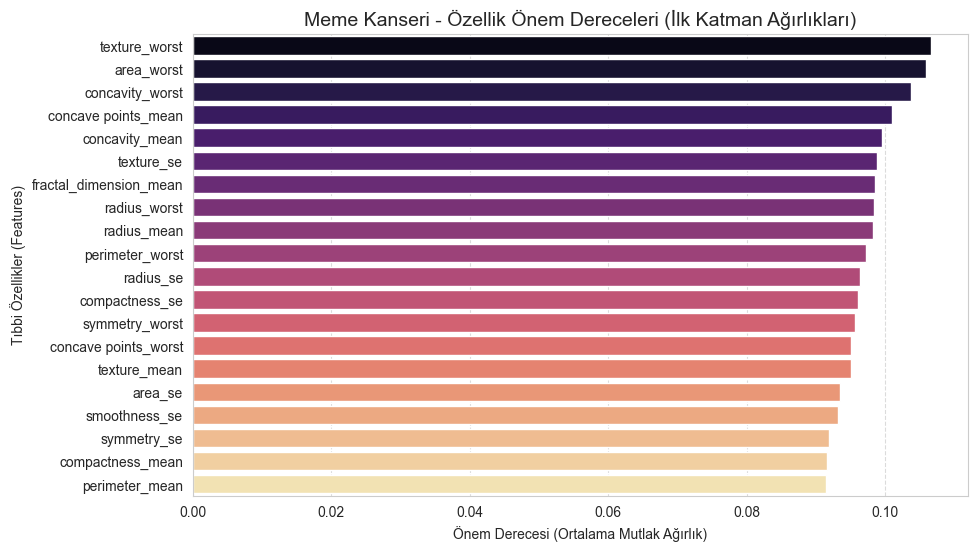


2) Permütasyon Önem Derecesi (Permutation Importance)


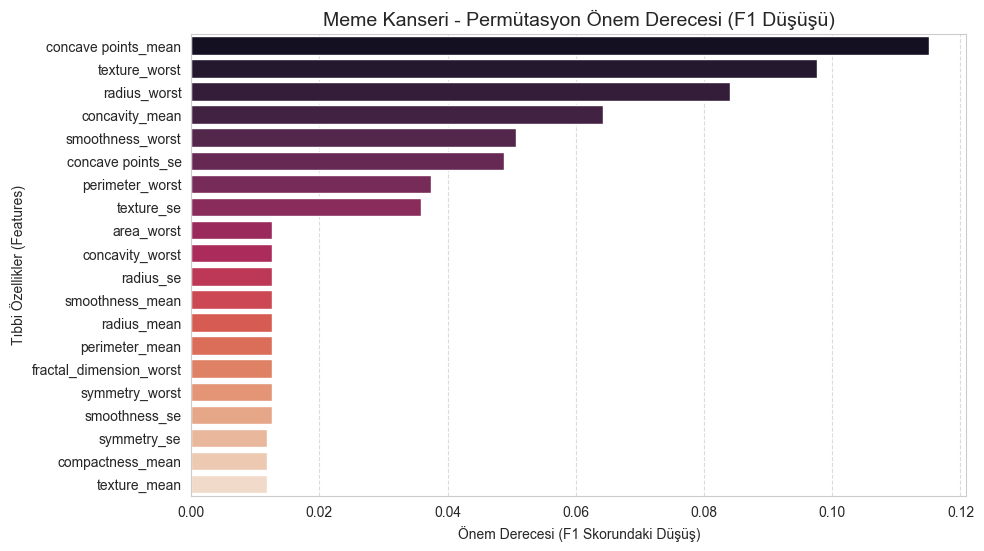

In [42]:
# ============================================================
# 42) ÖZELLİK ÖNEM DERECELERİ (FEATURE IMPORTANCE)
# Şampiyon modelin hangi kanser belirtilerine daha çok güvendiğini 
# iki farklı yöntemle (Ağırlıklar ve Permütasyon) analiz eder.
# Bu adım, modelin "Kara Kutu" (Black Box) olmadığını kanıtlar.
# ============================================================

print("Şampiyon modelin kararlarını yönlendiren en önemli tıbbi özellikler hesaplanıyor...\n")

# 1. Yöntem: İlk Katman Ağırlıklarına Göre Önem (Weight Importance)
# Ağın veriyi ilk gördüğü anda hangi özelliklere yüksek ağırlık verdiğini gösterir.
print("1) İlk Katman Ağırlıkları Analizi (Weight Importance)")
weight_imp_df = plot_first_layer_weight_importance(best_model, feature_names)

# 2. Yöntem: Veriyi Bozarak Ölçülen Önem (Permutation Importance)
# Bir özelliğin verileri rastgele karıştırıldığında modelin başarısının 
# (F1 Skoru) ne kadar düştüğünü ölçerek "gerçek" önemini kanıtlar.
print("\n2) Permütasyon Önem Derecesi (Permutation Importance)")
perm_imp_df = permutation_importance_for_pytorch(
    best_model,
    X_test,
    y_test.values, 
    feature_names,
    threshold=best_threshold
)

🔍 Integrated Gradients (Captum) ile Yapay Zeka Açıklanabilirliği (XAI) hesaplanıyor...

1) Global Açıklama (Genel Önem Derecesi):


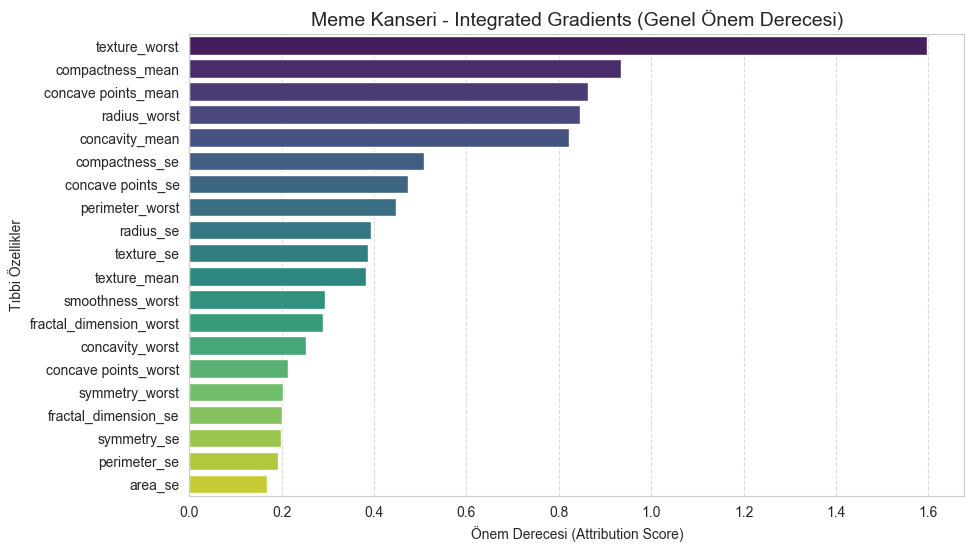


2) Lokal Açıklama (Tek Bir Hasta İçin Özel Karar Analizi - Örnek İndeks: 0):


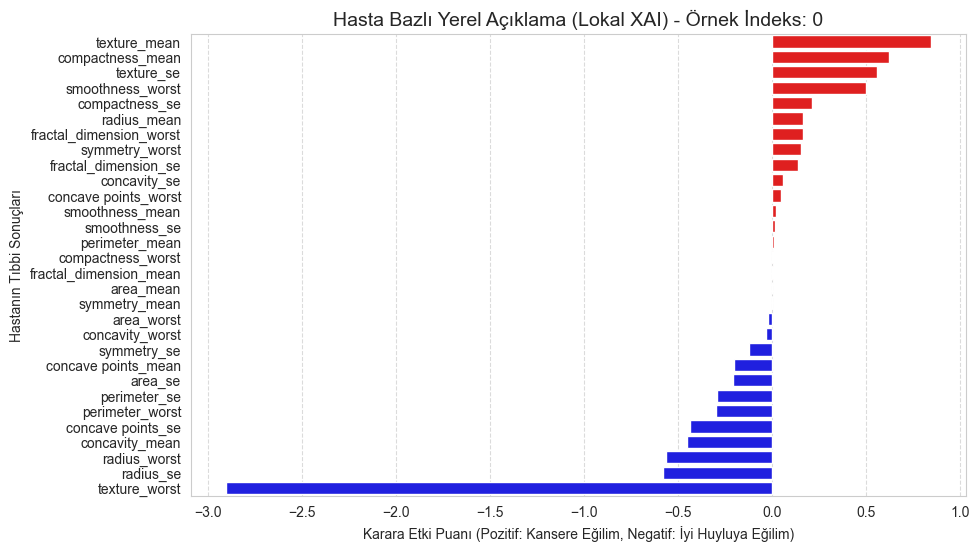

In [43]:
# ============================================================
# 43) INTEGRATED GRADIENTS (MODELİN KARARLARINI AÇIKLAMA)
# Şampiyon modelin hem genel (global) olarak hangi özelliklere odaklandığını
# hem de spesifik bir hasta (lokal) için neden o teşhisi koyduğunu açıklar.
# ============================================================

print("🔍 Integrated Gradients (Captum) ile Yapay Zeka Açıklanabilirliği (XAI) hesaplanıyor...\n")

# 1. Genel (Global) Açıklama
# Test setinden rastgele seçilen 50 hasta üzerinden modelin genel olarak hangi özelliklere ağırlık verdiğini gösterir.
print("1) Global Açıklama (Genel Önem Derecesi):")
ig_global_df = plot_integrated_gradients_global(
    model=best_model, 
    X_reference_np=X_train, 
    X_samples_np=X_test, 
    feature_names=feature_names, 
    sample_count=50
)

# 2. Yerel (Lokal) Açıklama
# Sadece test setindeki İLK hasta (index=0) için modelin neden "Kanserli" veya "Sağlıklı" dediğini analiz eder.
print("\n2) Lokal Açıklama (Tek Bir Hasta İçin Özel Karar Analizi - Örnek İndeks: 0):")
ig_local_df = plot_integrated_gradients_local(
    model=best_model, 
    X_reference_np=X_train, 
    X_samples_np=X_test, 
    feature_names=feature_names, 
    sample_index=0
)

🌌 Şampiyon modelin gizli uzay (Latent Space) haritası çıkarılıyor...

PCA ve t-SNE algoritmaları test verileri üzerinde çalıştırılıyor, lütfen bekleyiniz...


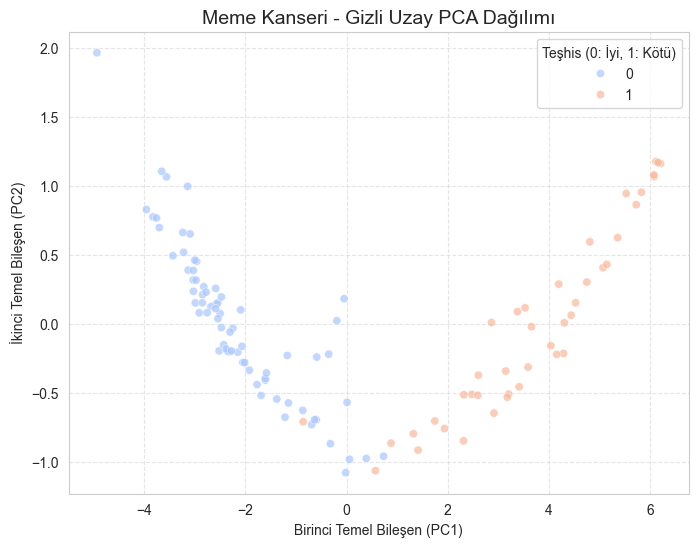

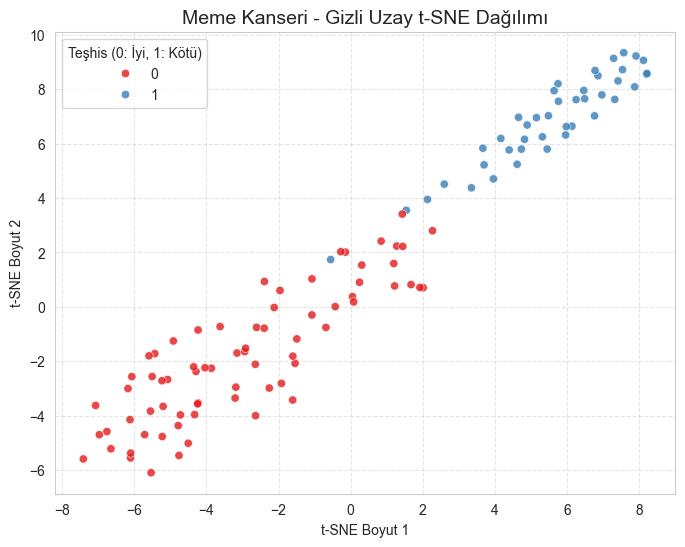


✅ Tüm analizler başarıyla tamamlandı! Proje sunuma hazırdır.


In [44]:
# ============================================================
# 44) GİZLİ UZAY GRAFİKLERİ (LATENT SPACE VISUALIZATION ON TEST SET)
# Şampiyon modelin hiç görmediği test verilerini karar aşamasından 
# hemen önce uzayda nasıl ayırdığını (kümelediğini) görselleştirir.
# ============================================================

print("🌌 Şampiyon modelin gizli uzay (Latent Space) haritası çıkarılıyor...\n")
print("PCA ve t-SNE algoritmaları test verileri üzerinde çalıştırılıyor, lütfen bekleyiniz...")

# Daha önce yazdığımız fonksiyonu çağırarak 2 boyutlu uzay grafiklerini çizdiriyoruz
plot_hidden_space_pca_tsne(best_model, X_test, y_test.values)

print("\n✅ Tüm analizler başarıyla tamamlandı! Proje sunuma hazırdır.")

In [46]:
# ============================================================
# 45) SONUÇLARI KAYDET (MODEL SAVING)
# Eğitim sonuçlarını (CSV) ve en iyi modelin ağırlıklarını (.pth) 
# diske veya Google Drive'a kalıcı olarak kaydeder.
# ============================================================

import os
import torch

# Dosya yolu (Yeni klasör yapısına uygun olarak "ai_model" yapıldı)
SAVE_DIR = "ai_model/meme_kanseri_pytorch_outputs"

# Eğer klasör yoksa oluştur
os.makedirs(SAVE_DIR, exist_ok=True)

# 10 modelin karşılaştırmalı sonuçlarını içeren tabloyu CSV olarak kaydet
results_df.to_csv(os.path.join(SAVE_DIR, "meme_kanseri_sonuclar.csv"), index=False)

# Şampiyon modelin öğrenilmiş ağırlıklarını (state_dict) kaydet
torch.save(best_model.state_dict(), os.path.join(SAVE_DIR, "en_iyi_meme_kanseri_modeli.pth"))

print("✅ Dosyalar başarıyla kaydedildi:")
print("Sonuç Raporu (CSV):", os.path.join(SAVE_DIR, "meme_kanseri_sonuclar.csv"))
print("Model Ağırlıkları (.pth):", os.path.join(SAVE_DIR, "en_iyi_meme_kanseri_modeli.pth"))

✅ Dosyalar başarıyla kaydedildi:
Sonuç Raporu (CSV): ai_model/meme_kanseri_pytorch_outputs\meme_kanseri_sonuclar.csv
Model Ağırlıkları (.pth): ai_model/meme_kanseri_pytorch_outputs\en_iyi_meme_kanseri_modeli.pth


# Sonuçları Nasıl Yorumlamalı?

## 1) Loss
- Train loss ve validation loss birlikte düşüyorsa öğrenme sağlıklı olabilir.
- Train loss düşerken validation loss artıyorsa overfitting olabilir.

## 2) Accuracy
- Veri dengeliyse yararlıdır.
- Veri dengesizse tek başına yeterli değildir.

## 3) Precision
- Pozitif tahminlerin ne kadarının doğru olduğunu gösterir.

## 4) Recall
- Gerçek pozitiflerin ne kadarını yakaladığını gösterir.

## 5) F1
- Precision ve recall arasında denge kurar.
- Dengesiz sınıflarda çok önemlidir.

## 6) ROC AUC
- Sınıfları ayırma gücünü gösterir.

## 7) PR Curve
- Özellikle dengesiz veri setlerinde çok değerlidir.

## 8) Threshold Analysis
- 0.5 her zaman en iyi threshold olmayabilir.
- Validation set ile en iyi threshold seçmek faydalı olabilir.

## 9) Feature Importance
- Hangi özelliklerin daha etkili olduğuna dair fikir verir.
- Tek yöntemle değil, birkaç yöntemle birlikte yorumlamak daha doğrudur.


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# 1. قراءة البيانات من الملف الموجود في مجلدك
df = pd.read_csv('data.csv')

# 2. حذف الأعمدة التي ليست فحوصات طبية (مثل الـ id والتشخيص)
# لتبقى الـ 30 خاصية طبية فقط
X = df.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1, errors='ignore')

# 3. بناء الـ Scaler وتعليمه على البيانات
scaler = StandardScaler()
scaler.fit(X)

# 4. حفظ الـ Scaler في ملف
joblib.dump(scaler, 'scaler.pkl')
print("تم تصنيع وحفظ الـ Scaler بنجاح! 🚀 الملف الآن جاهز للنقل.")

تم تصنيع وحفظ الـ Scaler بنجاح! 🚀 الملف الآن جاهز للنقل.


In [ ]:
import joblib
# افترض أن اسم المتغير الذي عملت به StandardScaler هو scaler
joblib.dump(scaler, 'scaler.pkl')



['scaler.pkl']